In [41]:
from pathlib import Path
import selfmadefunctions
import importlib
import matplotlib.pyplot as plt
import numpy as np
importlib.reload(selfmadefunctions)

# Author: Manou Liesker. Student number: 15250946

Selfmadefuntions imported/reloaded


<module 'selfmadefunctions' from 'c:\\Users\\DTA180363\\Documents\\GitHub\\paperstack\\Manou_version\\code\\selfmadefunctions.py'>

The cell below is used to read and track the videos, and save the y-coordinates into a CSV file (the y coordinates are already normalized). 

Having problems? Look at the outputfolder to see what part of tracking went wrong. Tweak the function accordingly 

(within selfmadefunctions.py there is a variabele named "treshold_value", that's probably the one to tweak. It might be worth it to make treshold_value one of the input parameters instead of a set value within the function).

In [29]:
inputfolder = Path(r"Z:\Video_files\Experiments\Raw_Videos\Distance_From_Edge_300t")
outputfolder = Path(r"Z:\Video_files\Experiments\Tracked_Videos\Distance_From_Edge_300t")
csvfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\Distance_From_Edge_300t")


for i in range(2, 16):
    for j in range(1, 4):
        filename = f"20h_300t_{i}cm_{j}.avi"
        print(filename)
        selfmadefunctions.track_video(100, video_inputfolder=inputfolder, 
                                video_outputfolder=outputfolder, 
                                csv_outputfolder=csvfolder, filename=filename, 
                                show=False, save_video=True, save_csv=True, BOTTOM_CROP = 55)

20h_300t_2cm_1.avi
Saved video to: Z:\Video_files\Experiments\Tracked_Videos\Distance_From_Edge_300t\20h_300t_2cm_1_tracked.avi
Saved as Z:\Clean_Data\Data_Manou_Thesis_Clean\Distance_From_Edge_300t\20h_300t_2cm_1_clean.csv
20h_300t_2cm_2.avi
Saved video to: Z:\Video_files\Experiments\Tracked_Videos\Distance_From_Edge_300t\20h_300t_2cm_2_tracked.avi
Saved as Z:\Clean_Data\Data_Manou_Thesis_Clean\Distance_From_Edge_300t\20h_300t_2cm_2_clean.csv
20h_300t_2cm_3.avi
Saved video to: Z:\Video_files\Experiments\Tracked_Videos\Distance_From_Edge_300t\20h_300t_2cm_3_tracked.avi
Saved as Z:\Clean_Data\Data_Manou_Thesis_Clean\Distance_From_Edge_300t\20h_300t_2cm_3_clean.csv
20h_300t_3cm_1.avi
Saved video to: Z:\Video_files\Experiments\Tracked_Videos\Distance_From_Edge_300t\20h_300t_3cm_1_tracked.avi
Saved as Z:\Clean_Data\Data_Manou_Thesis_Clean\Distance_From_Edge_300t\20h_300t_3cm_1_clean.csv
20h_300t_3cm_2.avi
Saved video to: Z:\Video_files\Experiments\Tracked_Videos\Distance_From_Edge_300t\20h

The function COR_calculator_general is meant to be able to read a clean csv file, and be given the name of the variable you are changing (such as thickness etc.) to ouput graphs (if Find_Plot = true) to check if everything went right. The function returns the calculated COR.

In [9]:
inputfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\Distance_From_Edge")

variable_type = "distance from edge"
edge = [i for i in range(2, 16) for _ in range(1, 4)]
COR = []

for i in range(2, 16):
    variable_value = f"{i} cm"
    
    for j in range(1, 4):
        filename = f"20h_100t_{i}cm_{j}_clean"
        cor_value = selfmadefunctions.COR_calculator_general(inputfolder=inputfolder, 
                                                                    variable_type=variable_type, 
                                                                    variable_value=variable_value, 
                                                                    filename=filename, Find_Plot=False,
                                                                    Fit_Plot=False, Fit_Report=False)
        COR.append(cor_value)



avg_cor = []
cor_err = []
x = [i for i in range(2, 16)]


for i in range(14):
    temp_cor = []
    for j in range(3):
        temp_cor.append(COR[3*i + j])
    avg_cor.append(sum(temp_cor)/3)
    cor_err.append(np.std(temp_cor)/np.sqrt(3))

c:\Users\DTA180363\Documents\GitHub\paperstack\Manou_version\code\selfmadefunctions.py:355: RuntimeWarning: invalid value encountered in sqrt
  COR = np.sqrt(bounce_height / drop_height)


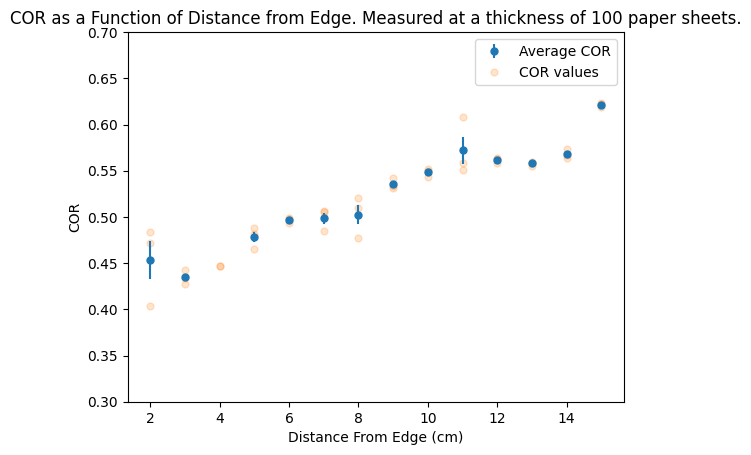

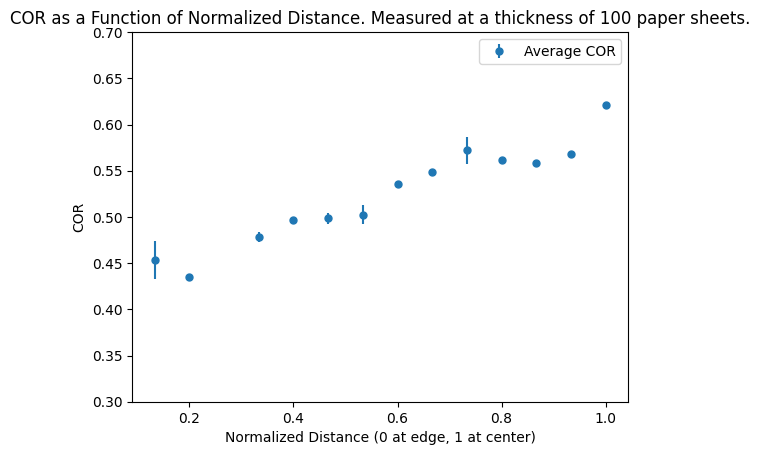

In [9]:
plt.errorbar(x, avg_cor, yerr=cor_err, fmt = 'o', markersize=5, label='Average COR', zorder = 2)
plt.errorbar(edge, COR, fmt = 'o', markersize=5, label='COR values', zorder = 1, alpha = 0.2)
plt.ylim(0.3, 0.7)
plt.xlabel('Distance From Edge (cm)')
plt.ylabel('COR')
plt.title('COR as a Function of Distance from Edge. Measured at a thickness of 100 paper sheets.')
plt.legend()
plt.show()

#normalized distance values
normalized_distance = []
for t in x:
    normalized_distance.append(t/15)

plt.errorbar(normalized_distance, avg_cor, yerr=cor_err, fmt = 'o', markersize=5, label='Average COR', zorder = 2)
plt.ylim(0.3, 0.7)
plt.xlabel('Normalized Distance (0 at edge, 1 at center)')
plt.ylabel('COR')
plt.title('COR as a Function of Normalized Distance. Measured at a thickness of 100 paper sheets.')
plt.legend()
plt.show()


In [37]:
importlib.reload(selfmadefunctions)
inputfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\Distance_From_Edge_10t")

variable_type = "distance from edge"
x = [i for i in range(1, 15)]
COR = []

for i in range(1, 15):
    variable_value = f"{i} cm"
    
    for j in range(1, 2):
        filename = f"20h_10t_{i}cm_{j}_clean"
        cor_value = selfmadefunctions.COR_calculator_general(inputfolder=inputfolder, 
                                                                    variable_type=variable_type, 
                                                                    variable_value=variable_value, 
                                                                    filename=filename, Find_Plot=False,
                                                                    Fit_Plot=False, Fit_Report=False)
        COR.append(cor_value)


plt.errorbar(x, COR, fmt = 'o', markersize=5, label='Average COR', zorder = 2)
plt.ylim(0.3, 0.7)
plt.xlabel('Distance From Edge (cm)')
plt.ylabel('COR')
plt.title('COR as a Function of Distance from Edge. Measured at a thickness of 10 paper sheets.')
plt.legend()
plt.show()

Selfmadefuntions imported/reloaded


TypeError: Improper input: func input vector length N=3 must not exceed func output vector length M=1

distance from edge = 2 cm
The first 78 frames are deleted, after that the ball drops.
The ball is released at y = 739.1066489655934 pixels.
The minima are located at 82 frames and 93 frames.


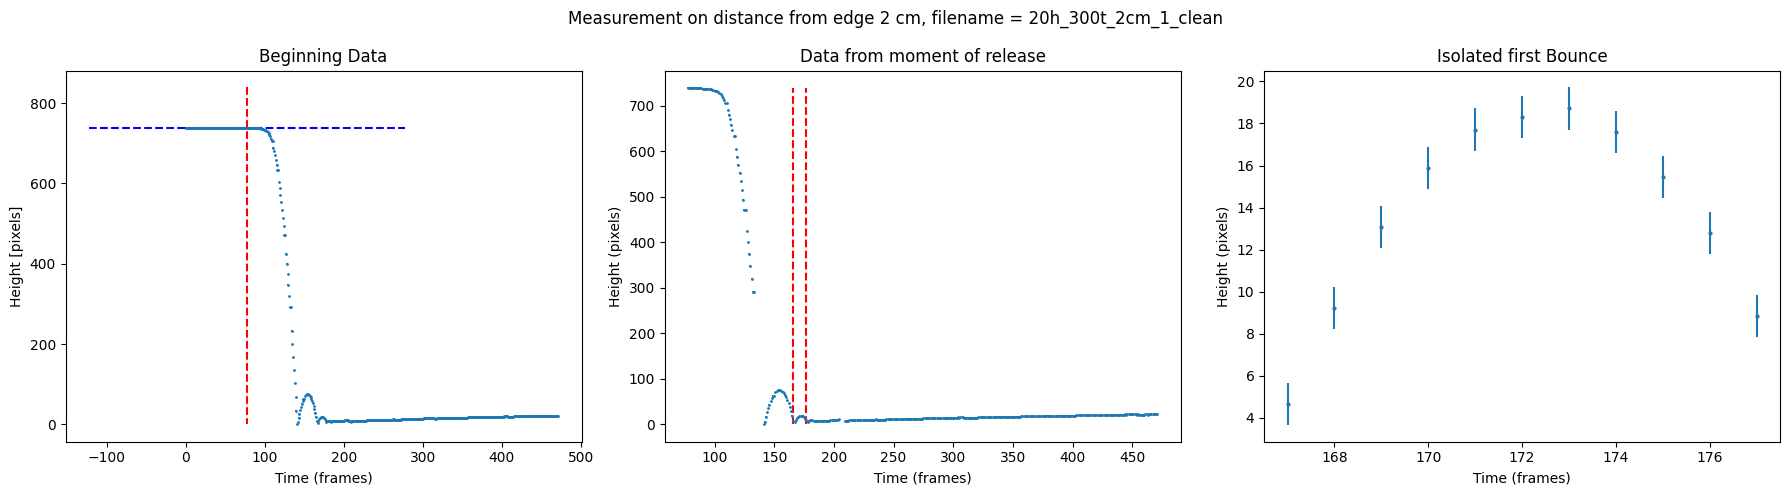

bounce height = 18.665545699416654 pixels
RMSE = 0.11 pixels


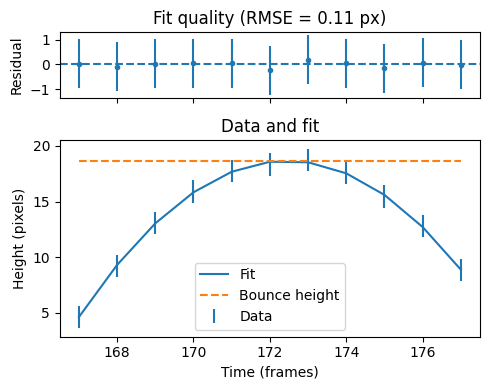

distance from edge = 2 cm
The first 51 frames are deleted, after that the ball drops.
The ball is released at y = 738.6580862387314 pixels.
The minima are located at 62 frames and 85 frames.


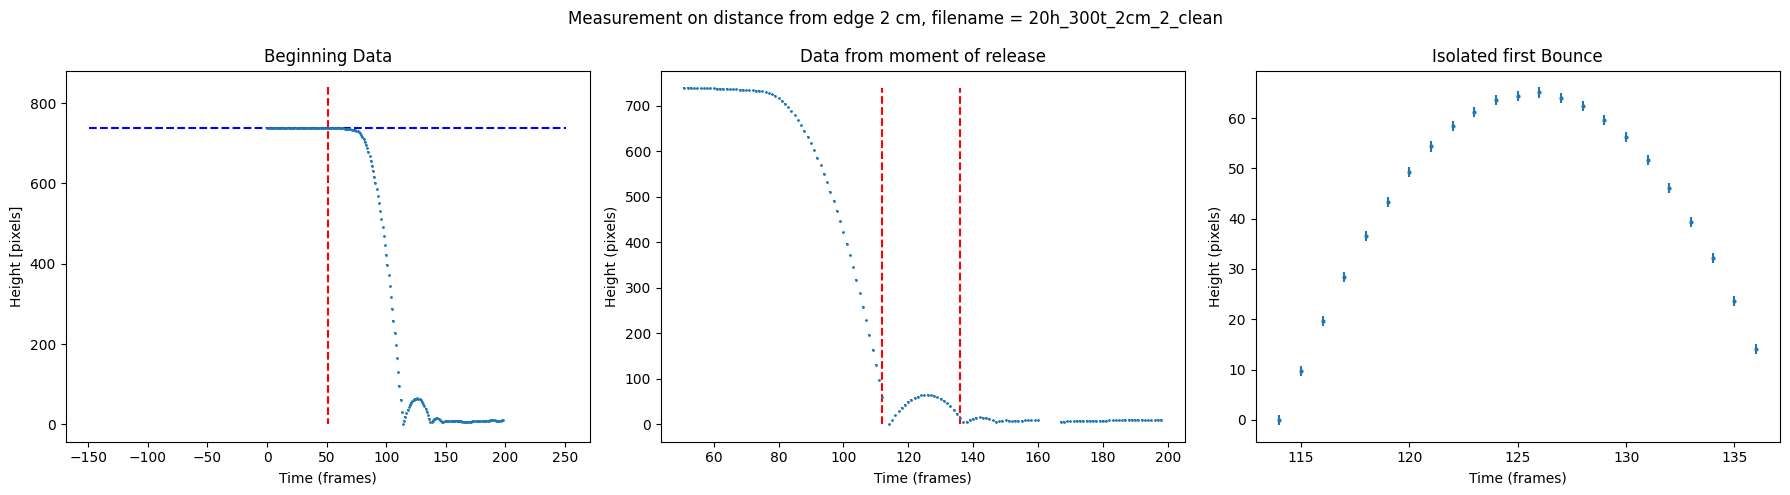

bounce height = 64.89131888629582 pixels
RMSE = 0.20 pixels


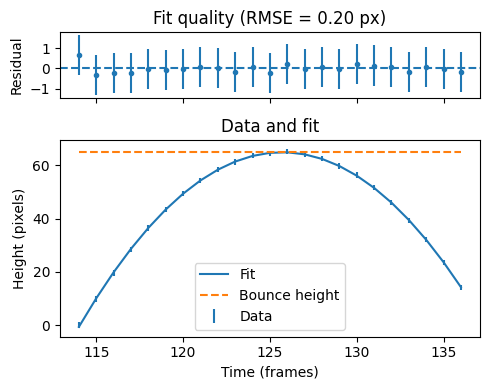

distance from edge = 2 cm
The first 21 frames are deleted, after that the ball drops.
The ball is released at y = 738.8711262282691 pixels.
The minima are located at 64 frames and 88 frames.


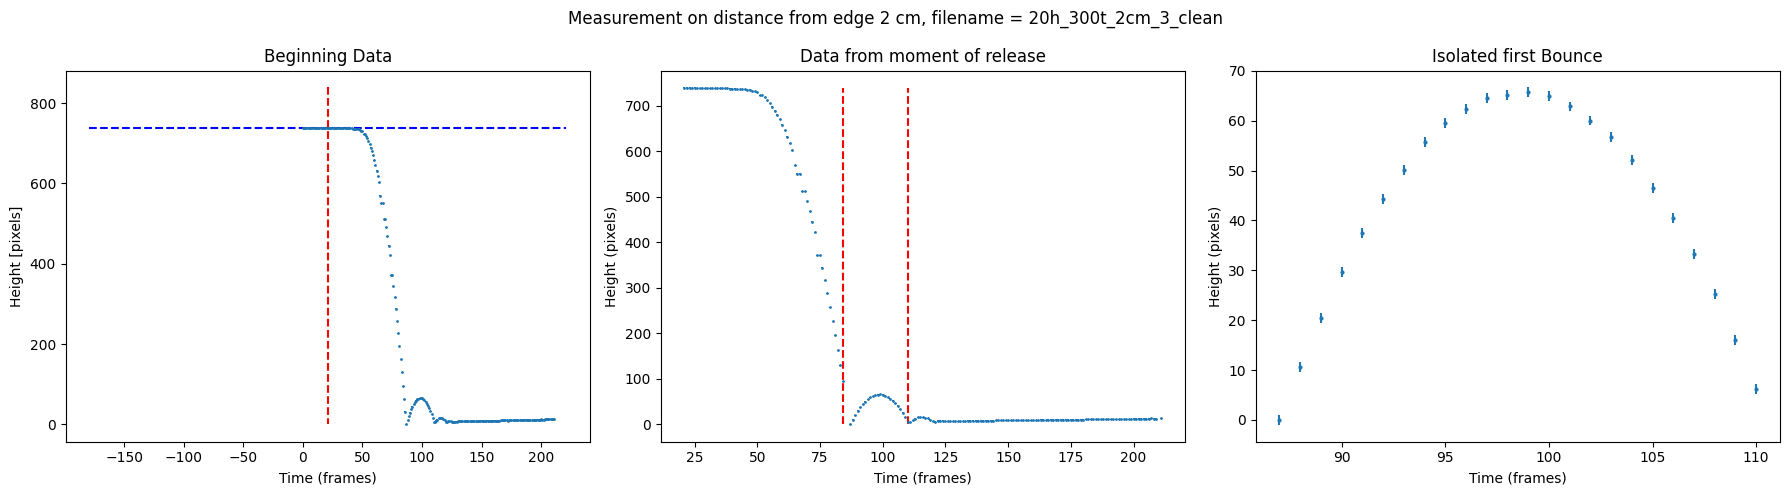

bounce height = 65.66185627236467 pixels
RMSE = 0.37 pixels


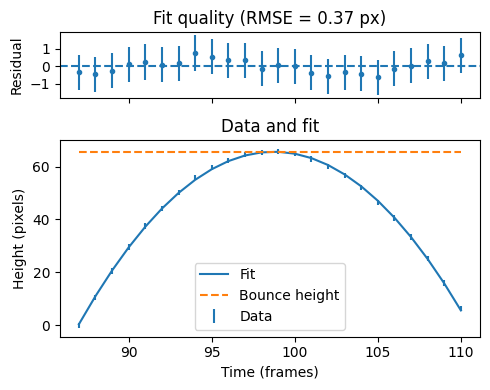

distance from edge = 3 cm
The first 44 frames are deleted, after that the ball drops.
The ball is released at y = 729.8613124464188 pixels.
The minima are located at 102 frames and 108 frames.


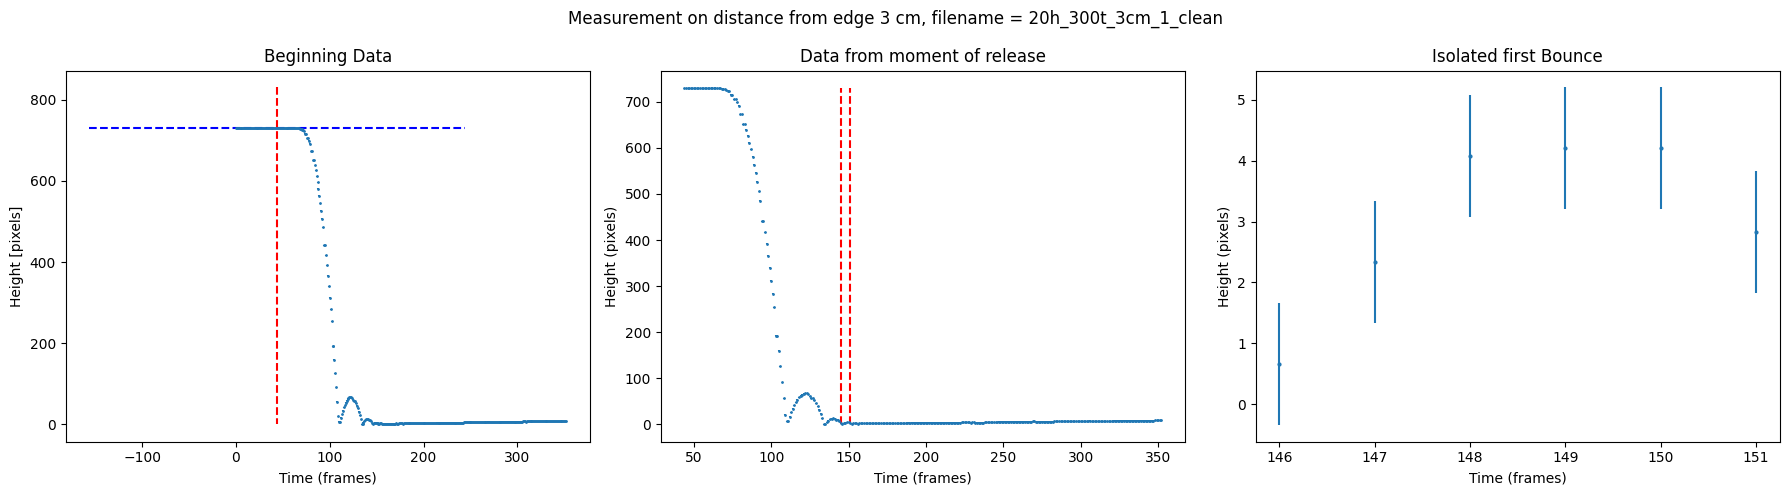

bounce height = 4.345930500333323 pixels
RMSE = 0.17 pixels


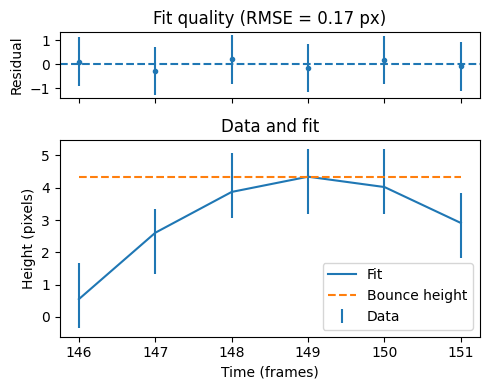

distance from edge = 3 cm
The first 7 frames are deleted, after that the ball drops.
The ball is released at y = 732.8818499805673 pixels.
The minima are located at 60 frames and 85 frames.


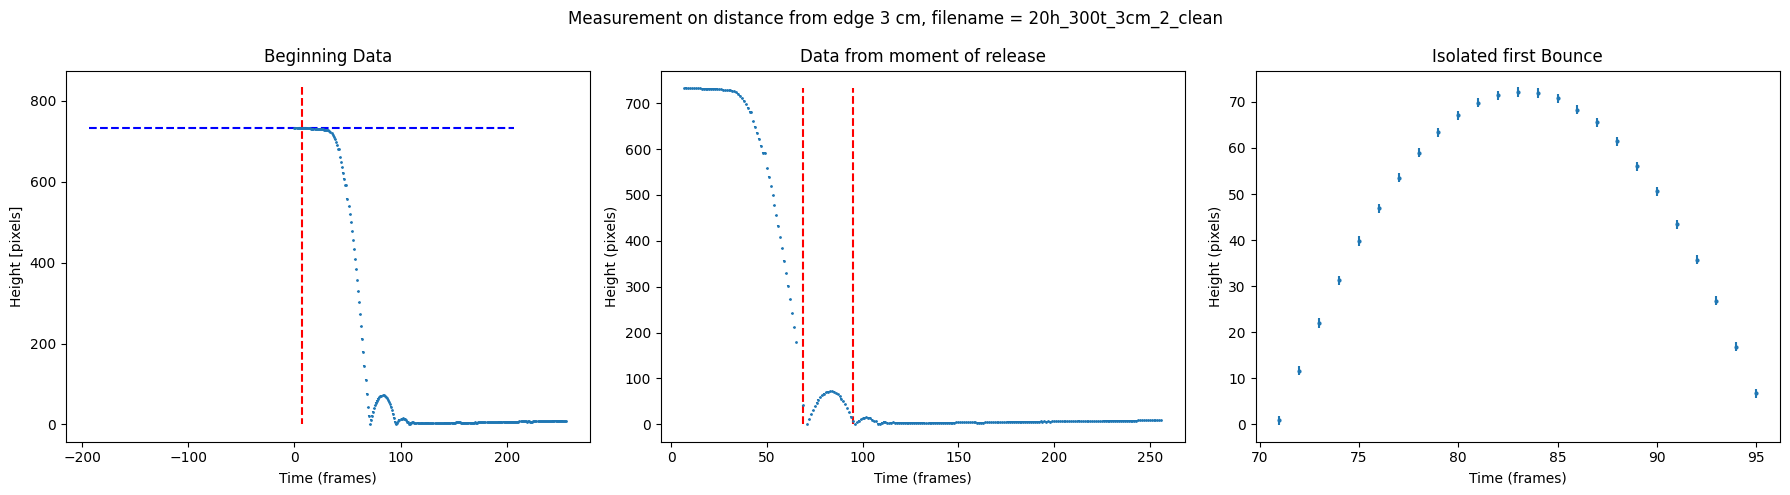

bounce height = 72.13160258469755 pixels
RMSE = 0.16 pixels


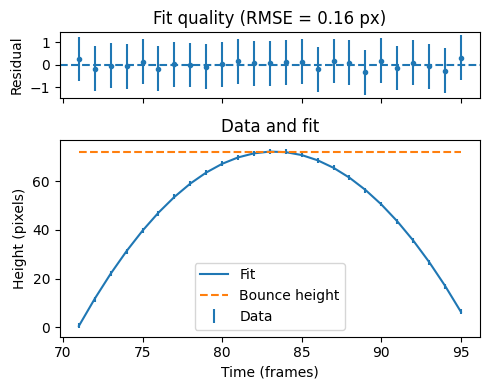

distance from edge = 3 cm
The first 69 frames are deleted, after that the ball drops.
The ball is released at y = 736.460970464135 pixels.
The minima are located at 0 frames and 127 frames.


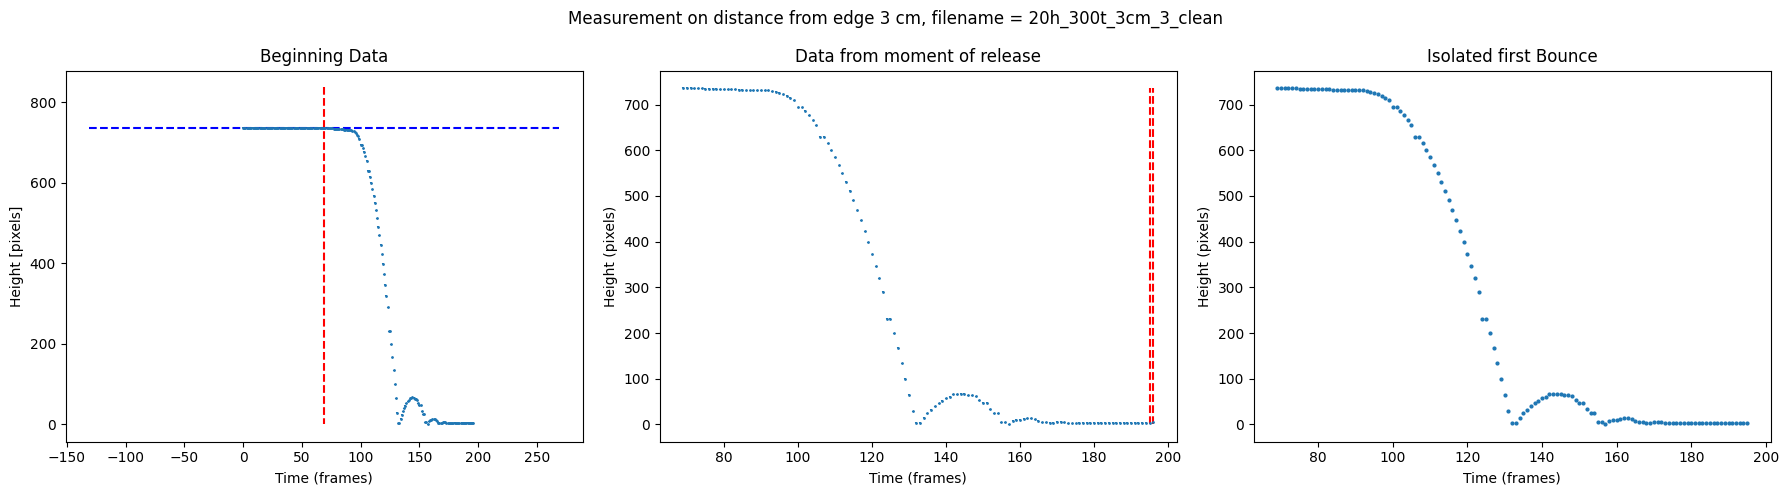

bounce height = -52.901849211333015 pixels
RMSE = 102.75 pixels


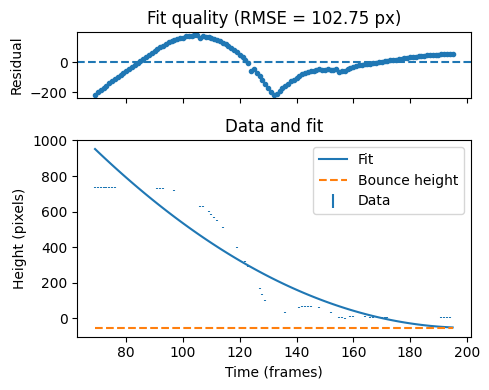

distance from edge = 4 cm
The first 59 frames are deleted, after that the ball drops.
The ball is released at y = 742.6158711903392 pixels.
The minima are located at 63 frames and 87 frames.


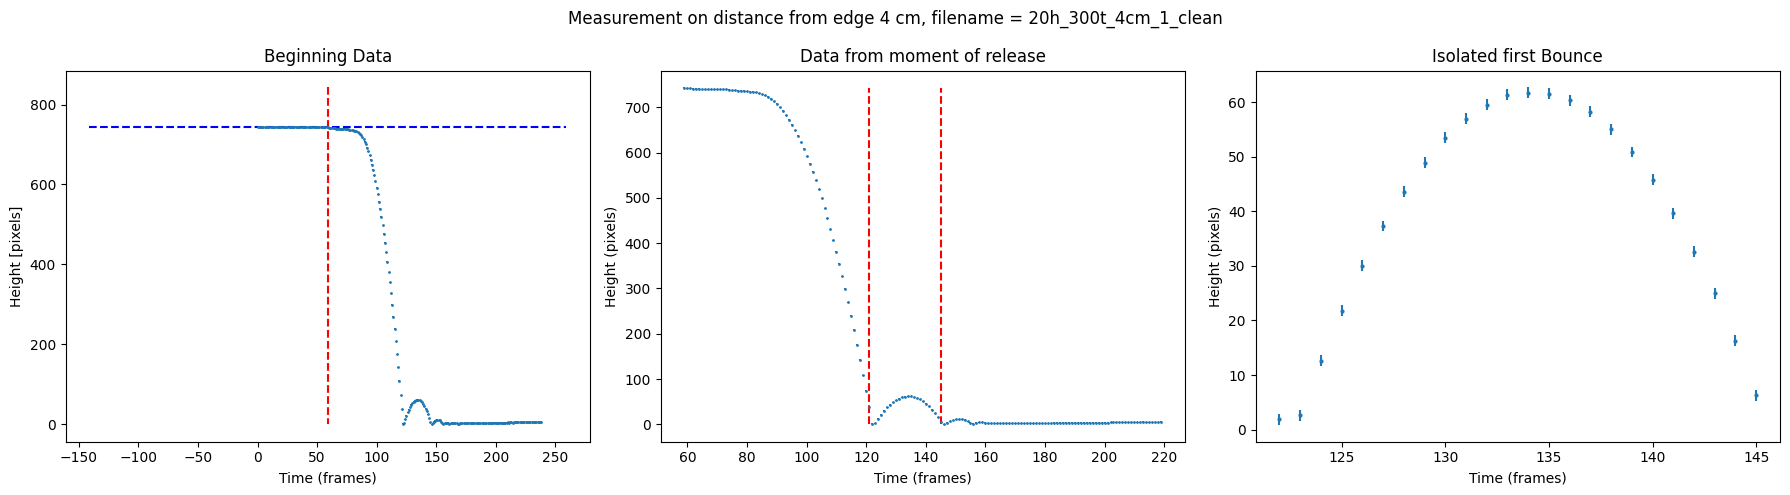

bounce height = 61.262598286265074 pixels
RMSE = 1.76 pixels


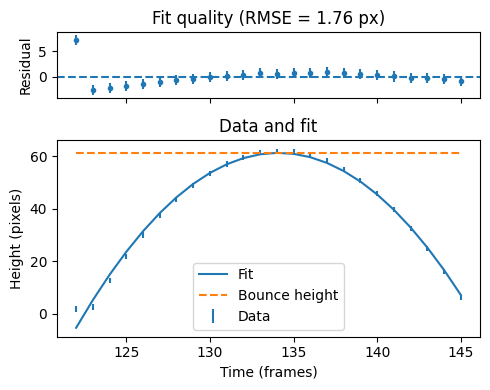

distance from edge = 4 cm
The first 23 frames are deleted, after that the ball drops.
The ball is released at y = 738.0709378733571 pixels.
The minima are located at 61 frames and 85 frames.


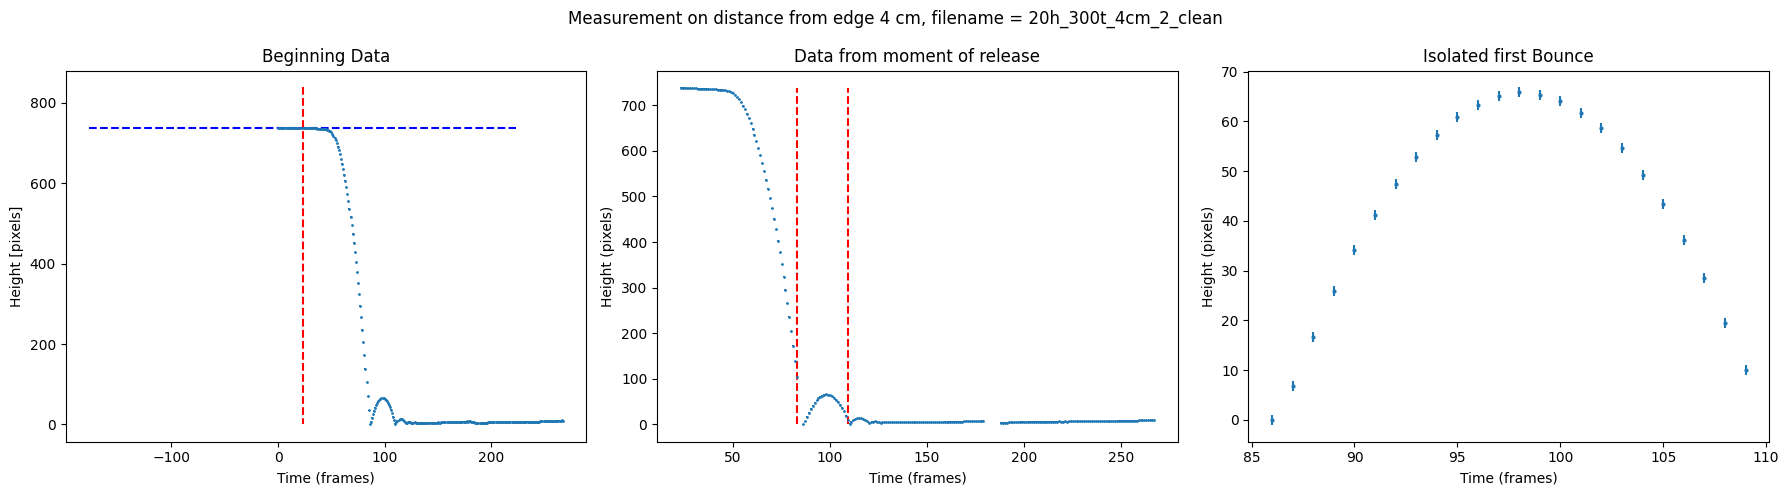

bounce height = 65.3469248640003 pixels
RMSE = 0.77 pixels


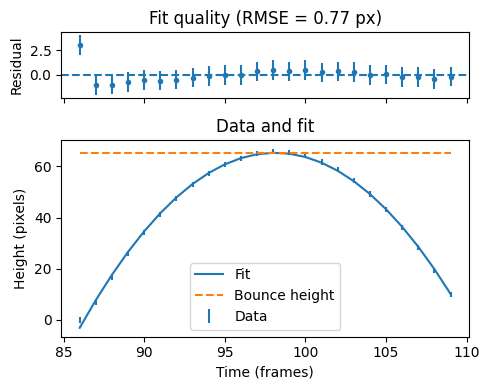

distance from edge = 4 cm
The first 39 frames are deleted, after that the ball drops.
The ball is released at y = 734.4340993328391 pixels.
The minima are located at 63 frames and 86 frames.


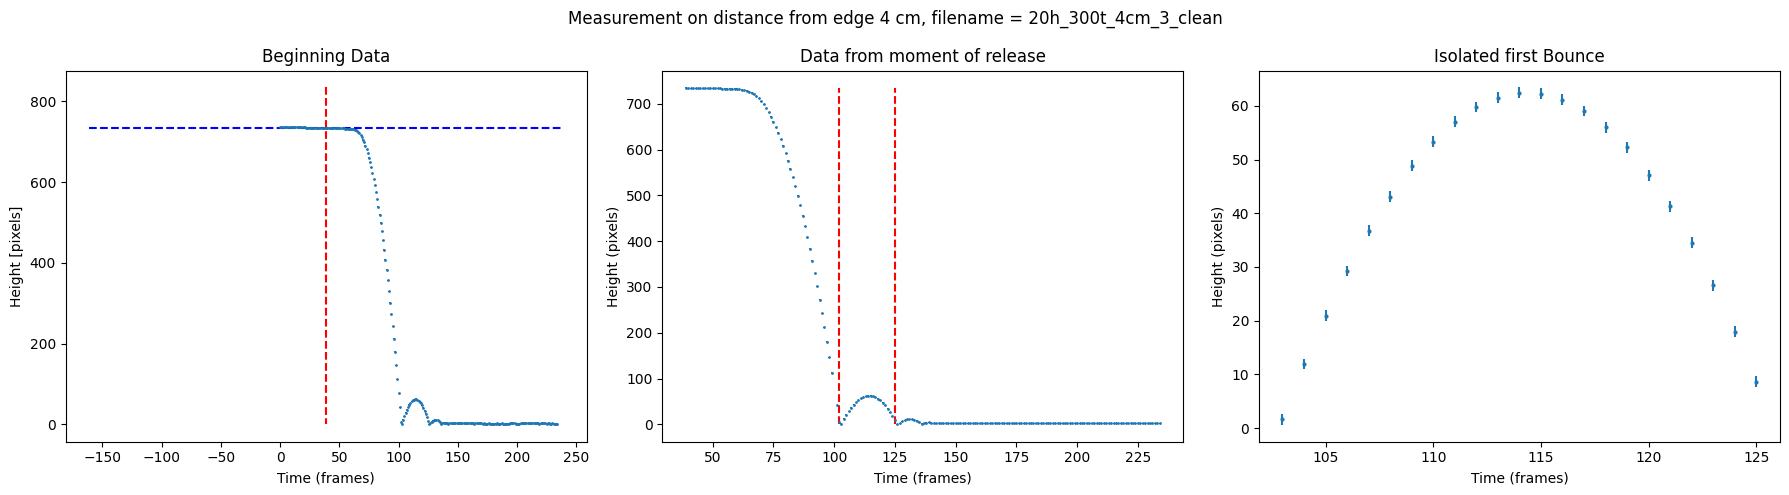

bounce height = 62.35032708805238 pixels
RMSE = 0.13 pixels


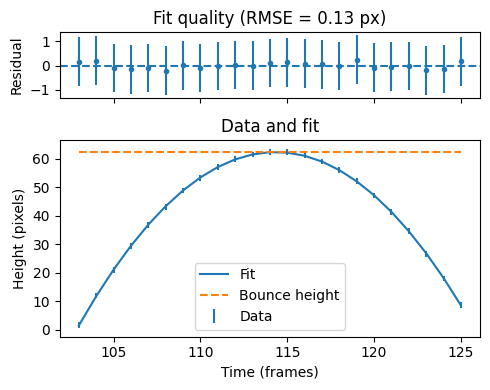

distance from edge = 5 cm
The first 47 frames are deleted, after that the ball drops.
The ball is released at y = 729.0888888888888 pixels.
The minima are located at 53 frames and 76 frames.


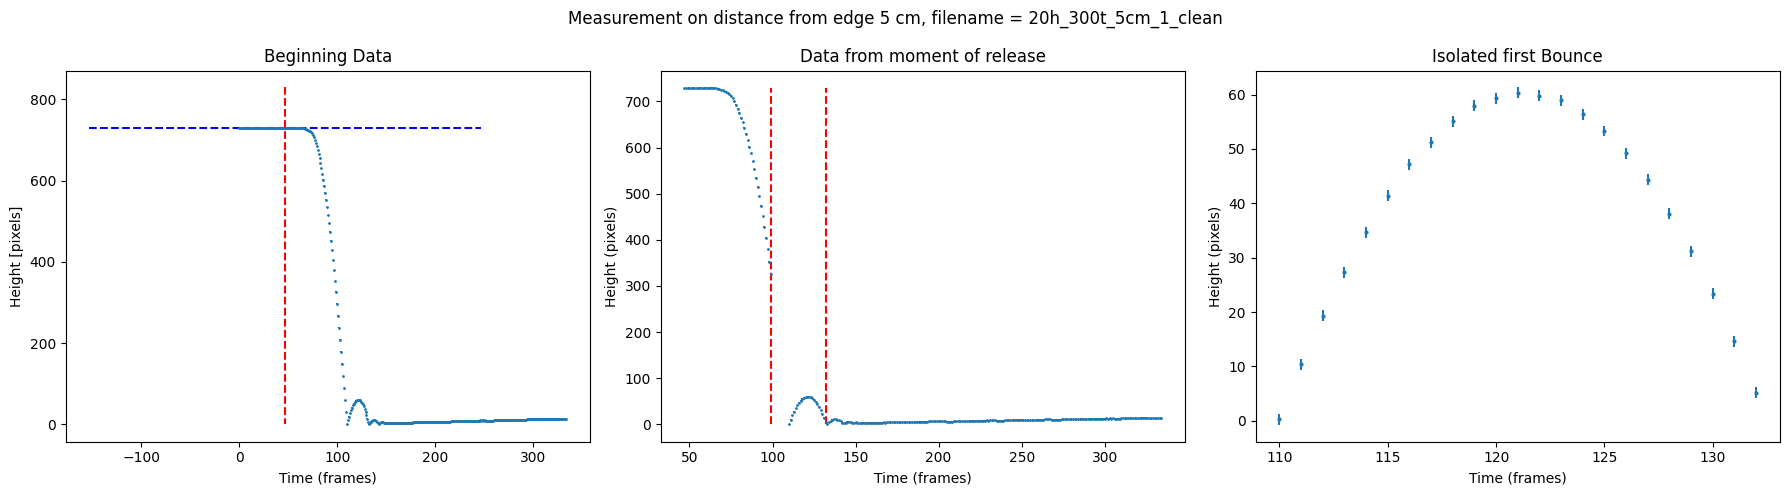

bounce height = 60.070553255521645 pixels
RMSE = 0.22 pixels


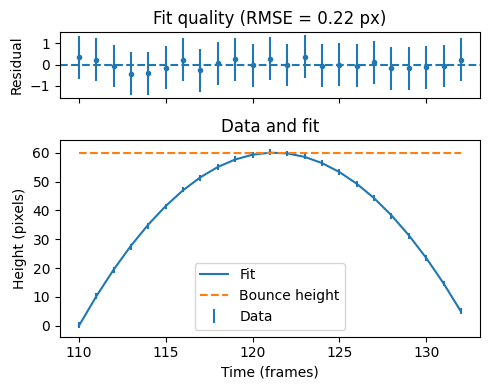

distance from edge = 5 cm
The first 14 frames are deleted, after that the ball drops.
The ball is released at y = 734.7697222222222 pixels.
The minima are located at 63 frames and 87 frames.


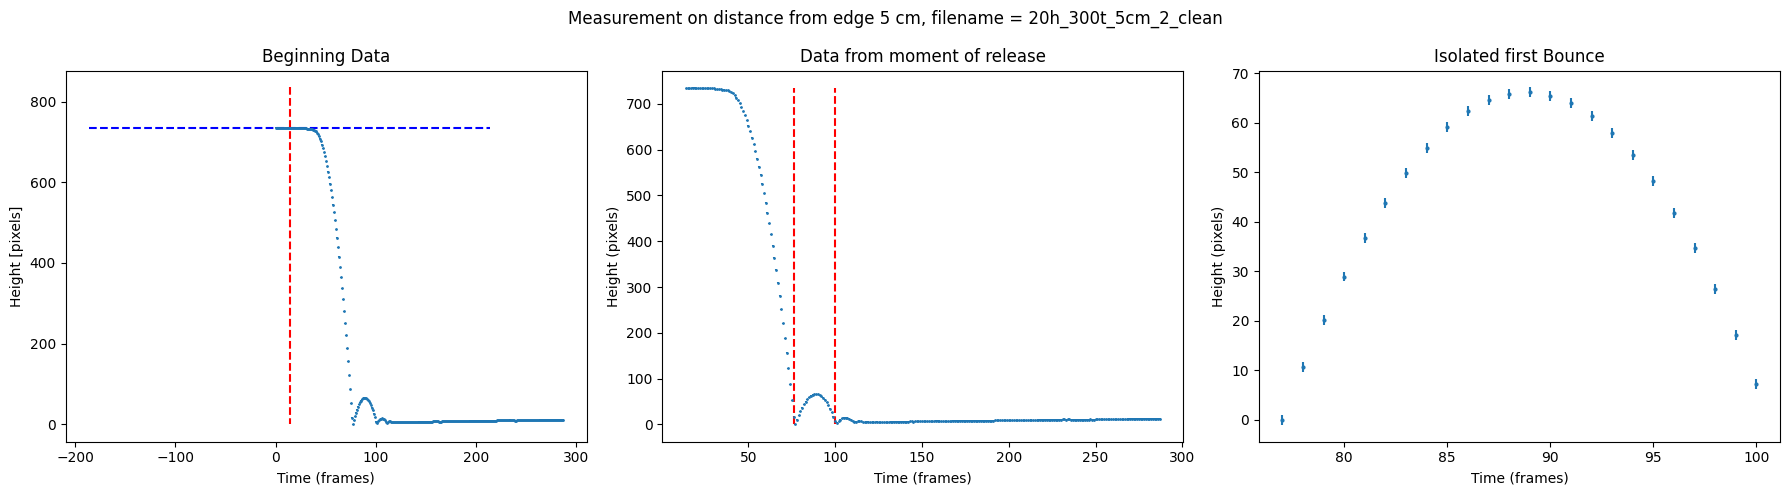

bounce height = 66.09938183922304 pixels
RMSE = 0.12 pixels


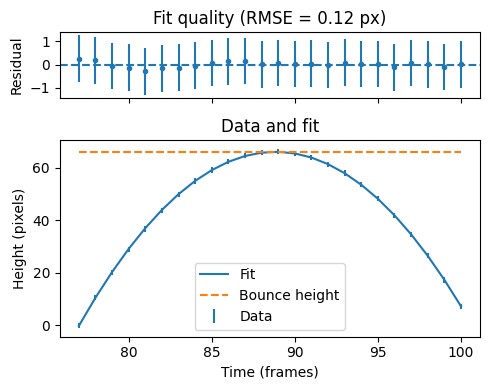

distance from edge = 5 cm
The first 40 frames are deleted, after that the ball drops.
The ball is released at y = 728.9825602126487 pixels.
The minima are located at 64 frames and 87 frames.


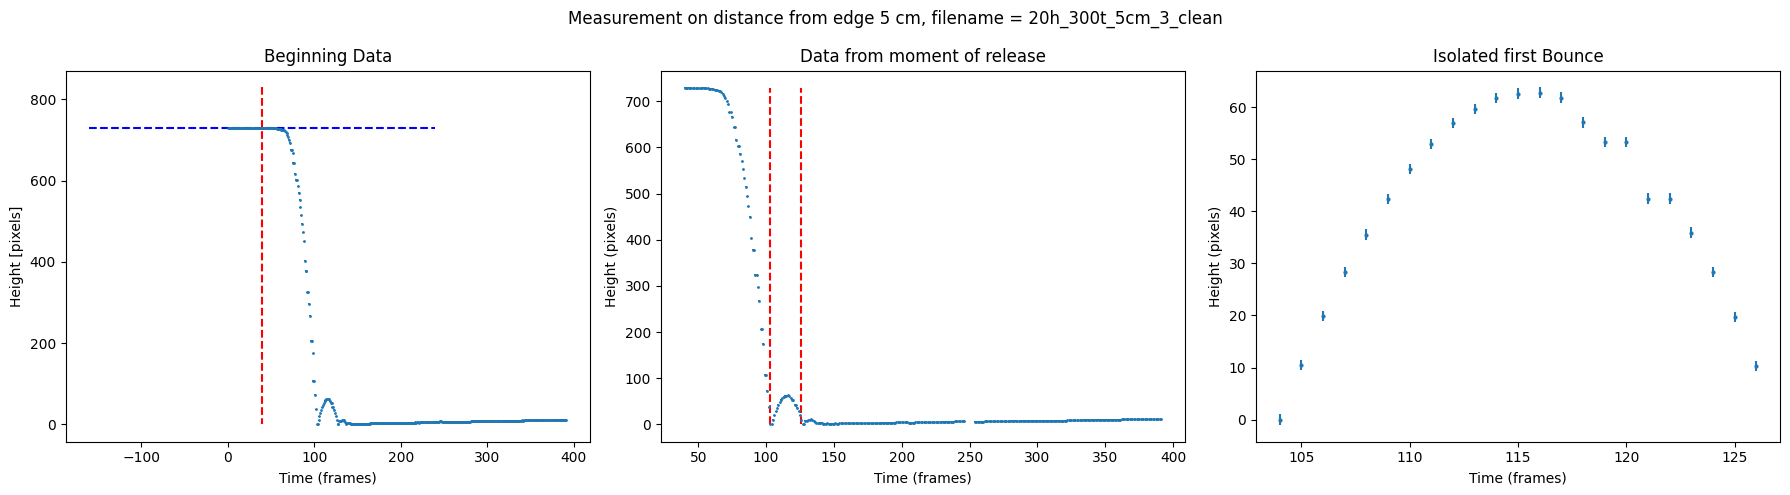

bounce height = 61.82159184595011 pixels
RMSE = 1.38 pixels


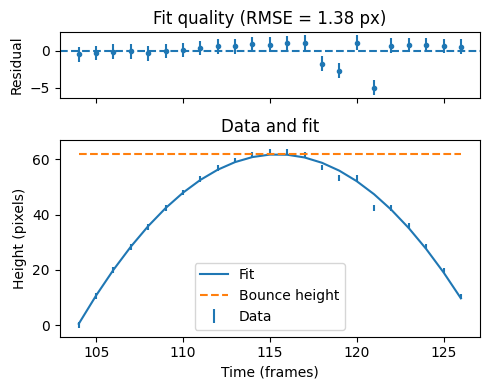

distance from edge = 6 cm
The first 12 frames are deleted, after that the ball drops.
The ball is released at y = 731.4190031152648 pixels.
The minima are located at 62 frames and 84 frames.


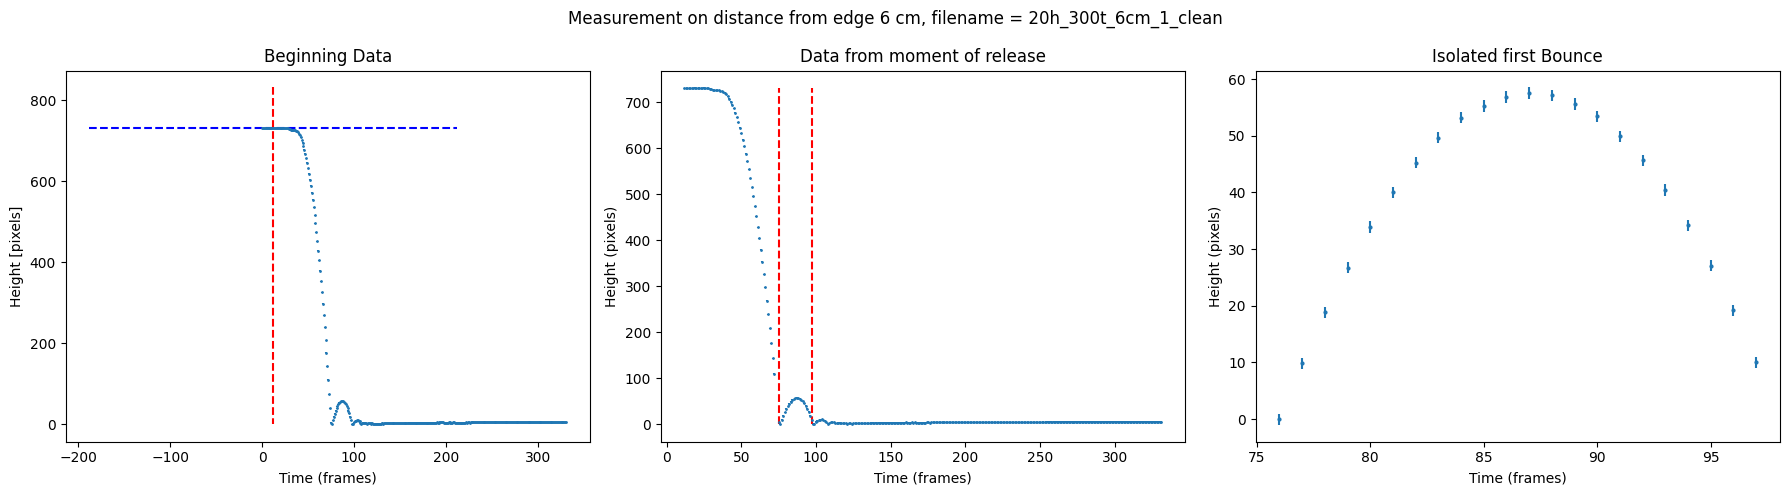

bounce height = 57.391240739180176 pixels
RMSE = 0.13 pixels


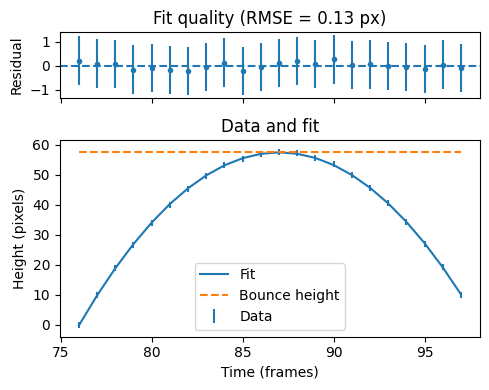

distance from edge = 6 cm
The first 17 frames are deleted, after that the ball drops.
The ball is released at y = 736.0218323586744 pixels.
The minima are located at 192 frames and 228 frames.


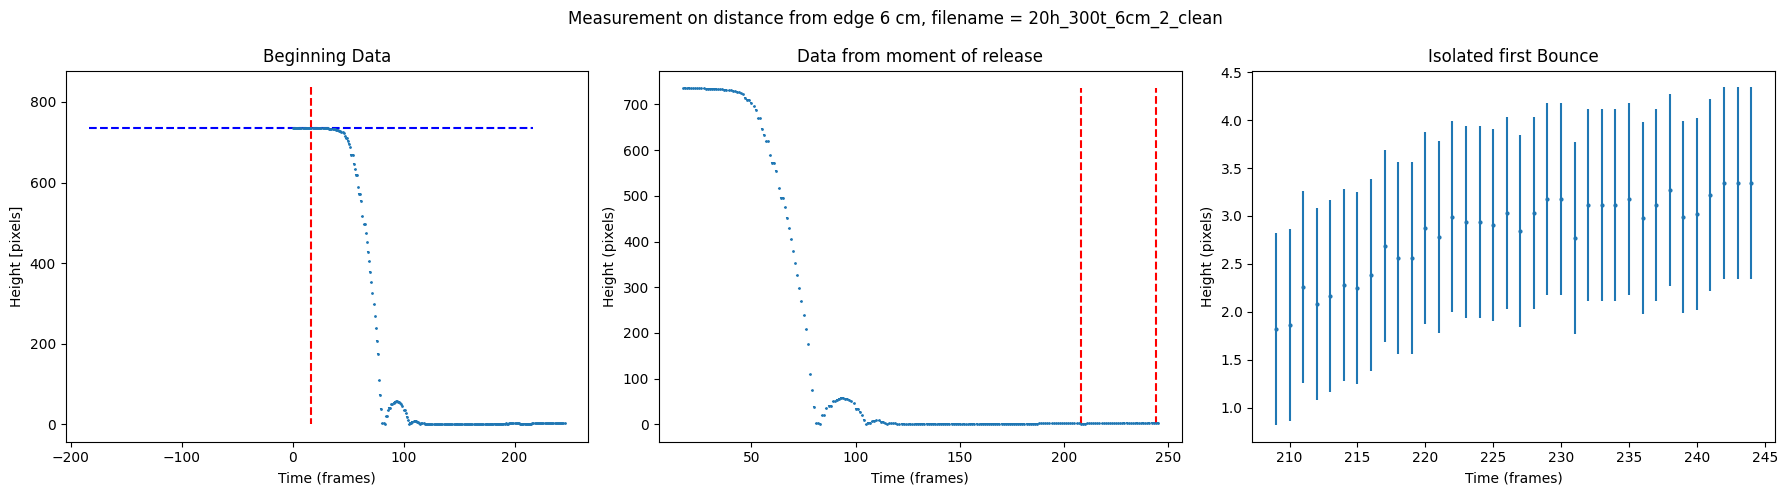

bounce height = 3.2036008597832404 pixels
RMSE = 0.13 pixels


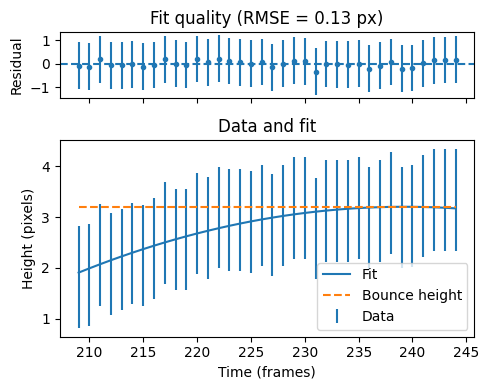

distance from edge = 6 cm
The first 42 frames are deleted, after that the ball drops.
The ball is released at y = 738.2511521351128 pixels.
The minima are located at 63 frames and 86 frames.


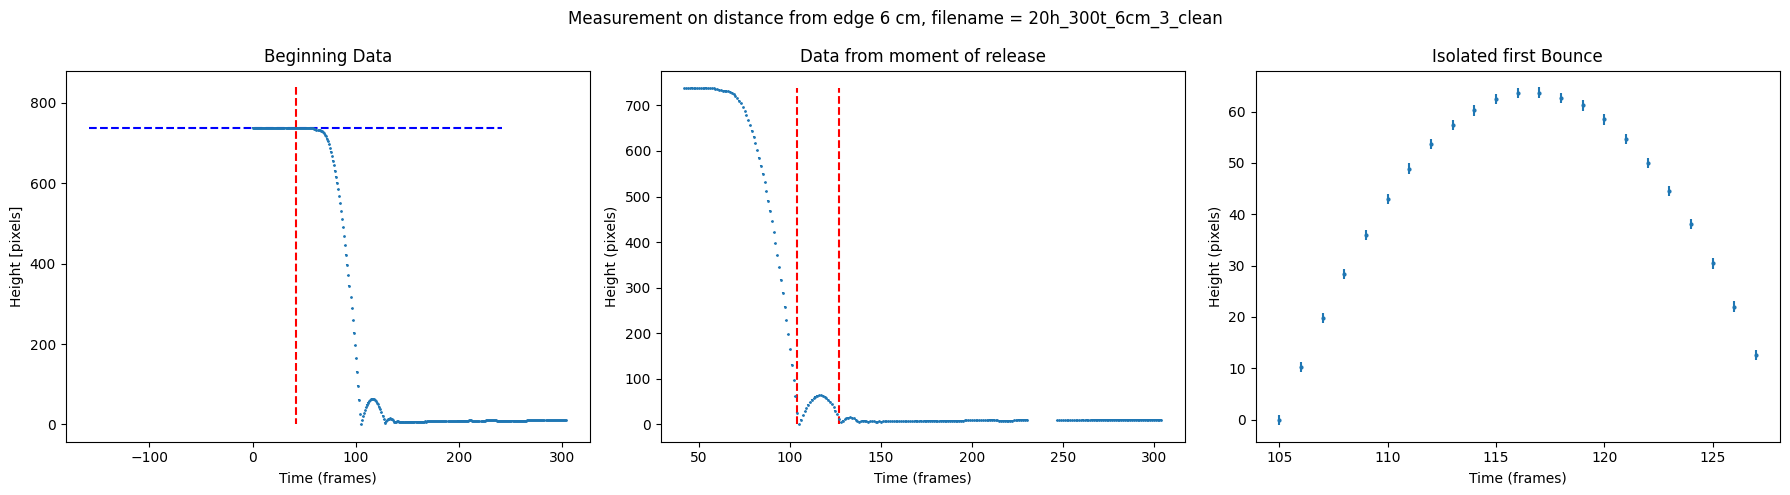

bounce height = 63.717376532084025 pixels
RMSE = 0.13 pixels


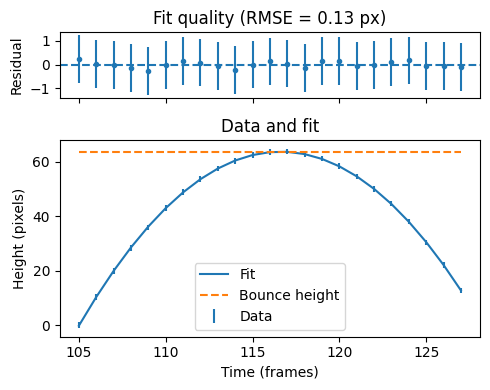

distance from edge = 7 cm
The first 31 frames are deleted, after that the ball drops.
The ball is released at y = 734.5427994227994 pixels.
The minima are located at 62 frames and 84 frames.


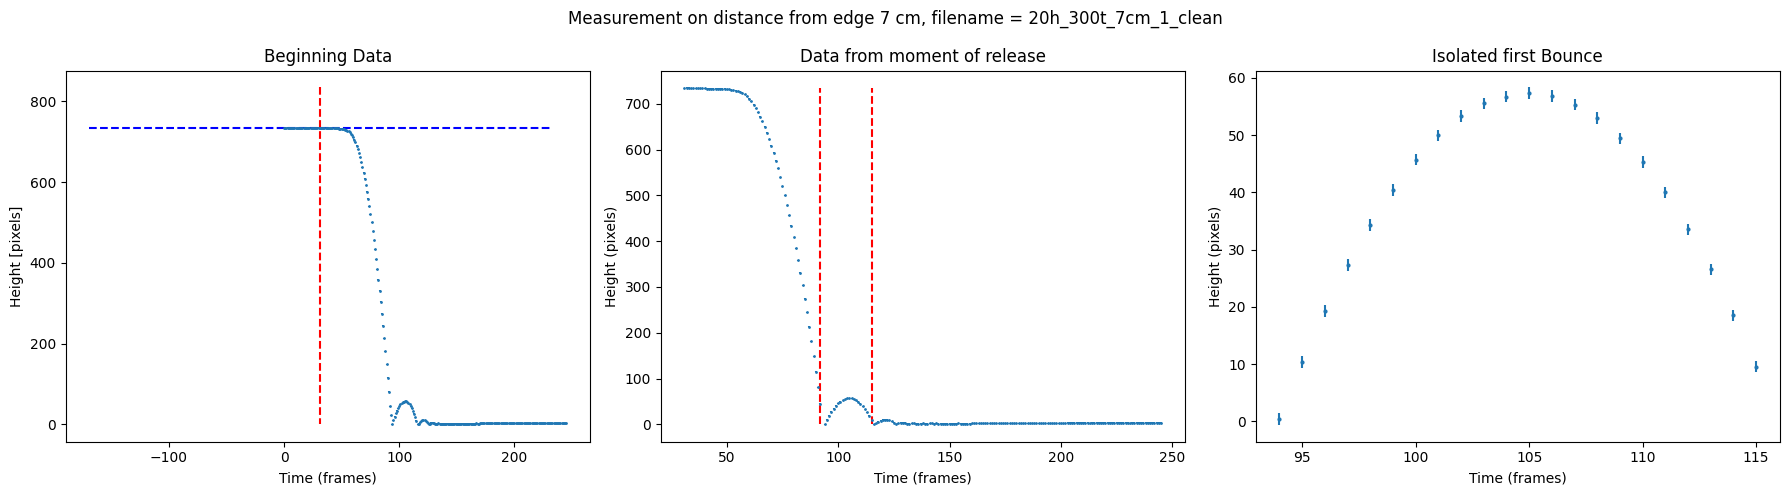

bounce height = 57.2870186886924 pixels
RMSE = 0.08 pixels


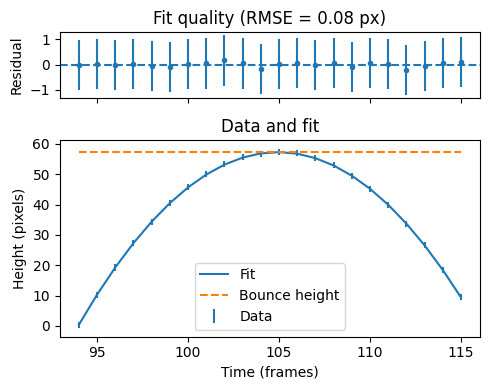

distance from edge = 7 cm
The first 29 frames are deleted, after that the ball drops.
The ball is released at y = 379.5587606837607 pixels.
The minima are located at 0 frames and 52 frames.


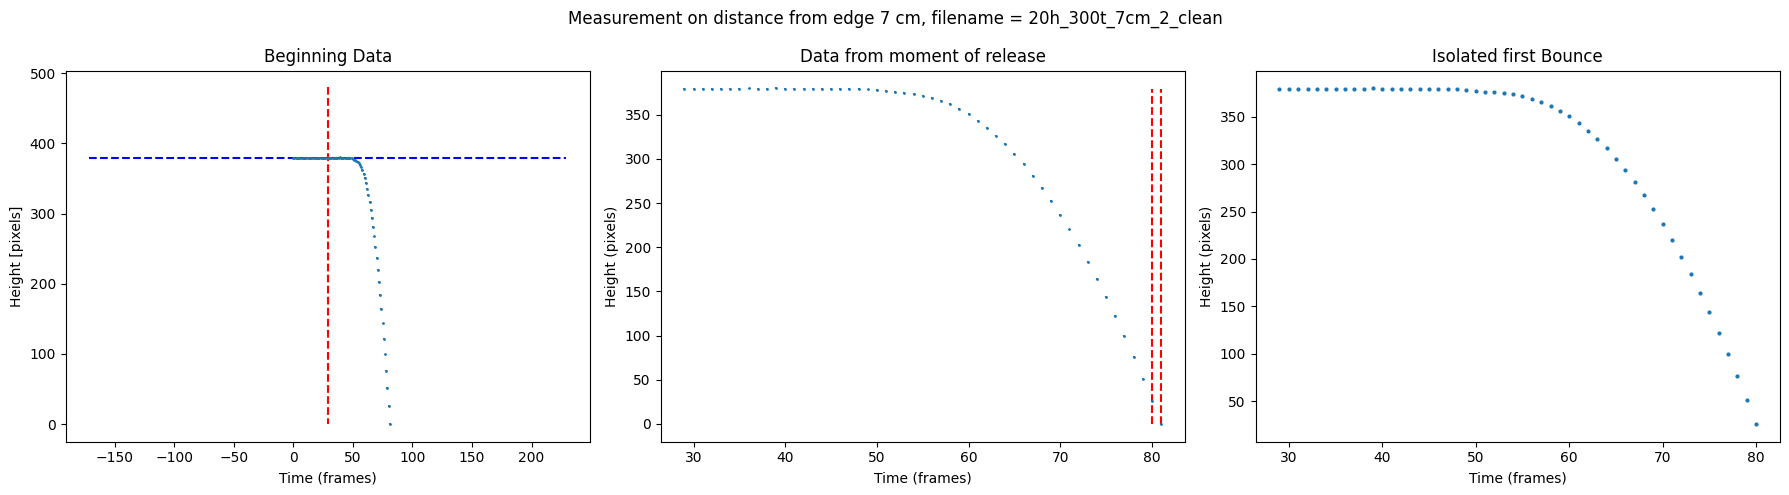

bounce height = 401.24457981933426 pixels
RMSE = 17.03 pixels


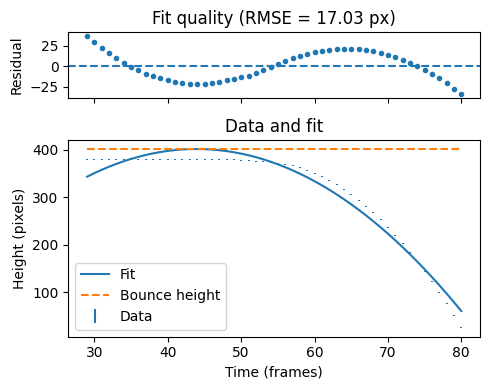

distance from edge = 7 cm
The first 31 frames are deleted, after that the ball drops.
The ball is released at y = 729.5909361955873 pixels.
The minima are located at 79 frames and 89 frames.


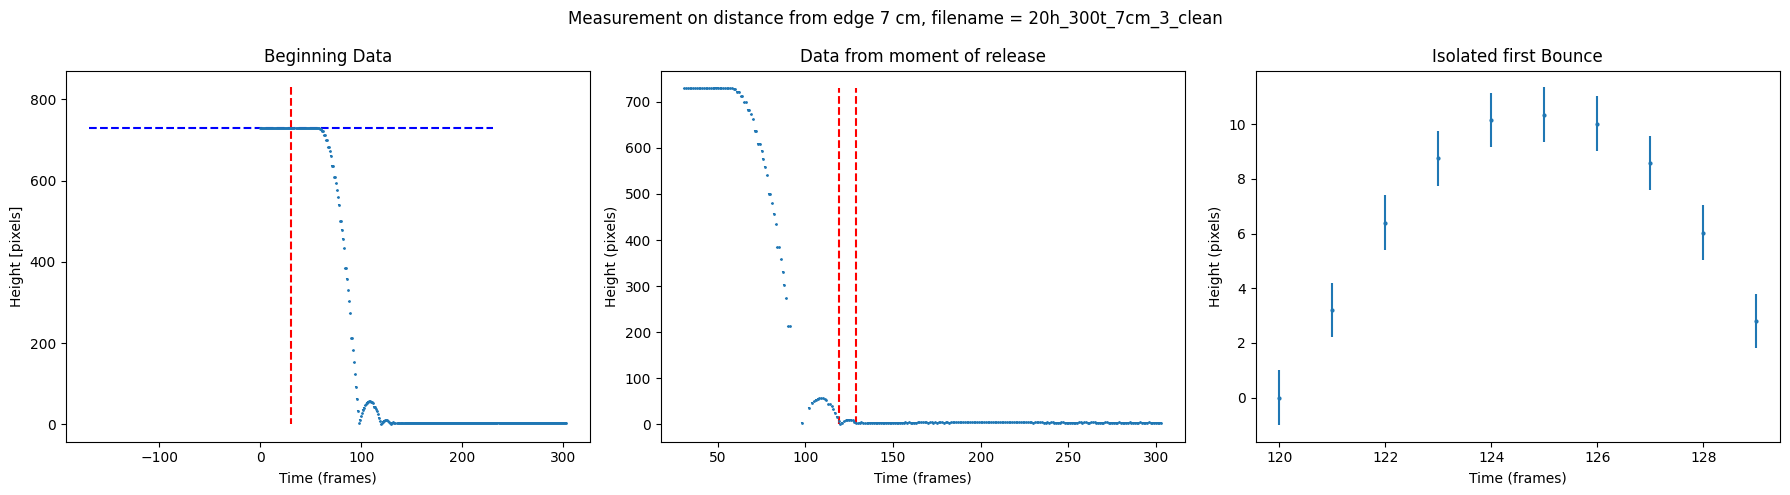

bounce height = 10.394110974147486 pixels
RMSE = 0.20 pixels


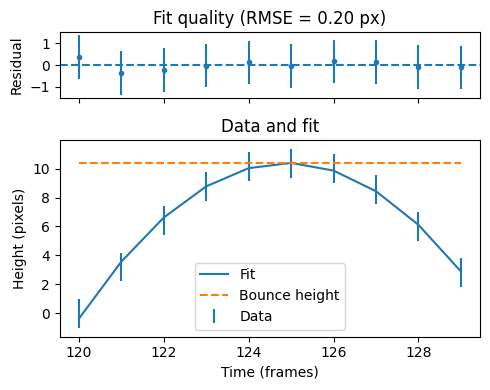

distance from edge = 8 cm
The first 16 frames are deleted, after that the ball drops.
The ball is released at y = 740.672109385371 pixels.
The minima are located at 59 frames and 81 frames.


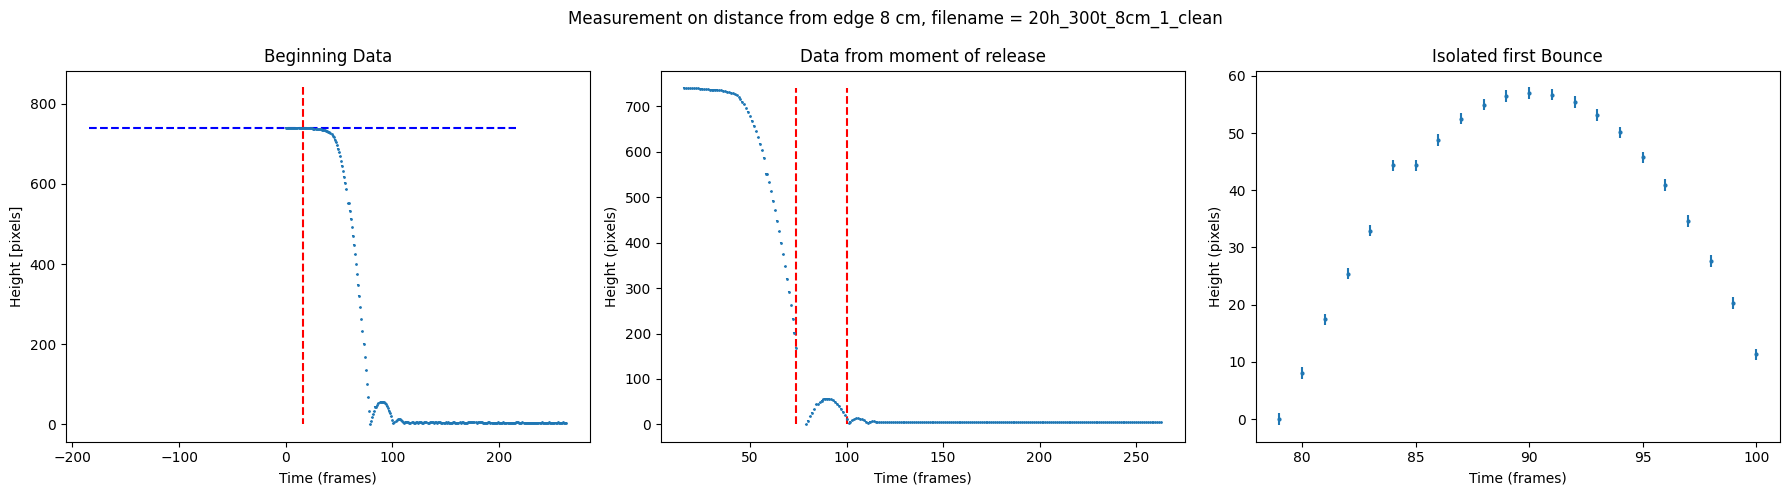

bounce height = 57.205667157417196 pixels
RMSE = 1.10 pixels


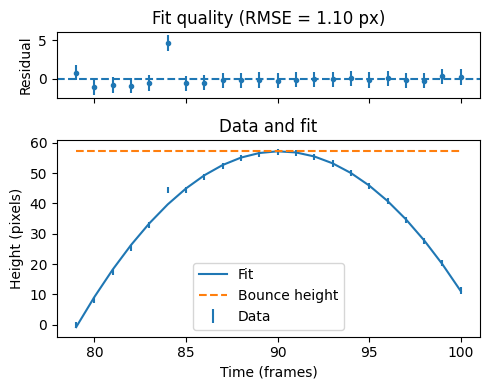

distance from edge = 8 cm
The first 37 frames are deleted, after that the ball drops.
The ball is released at y = 732.7651515151515 pixels.
The minima are located at 88 frames and 108 frames.


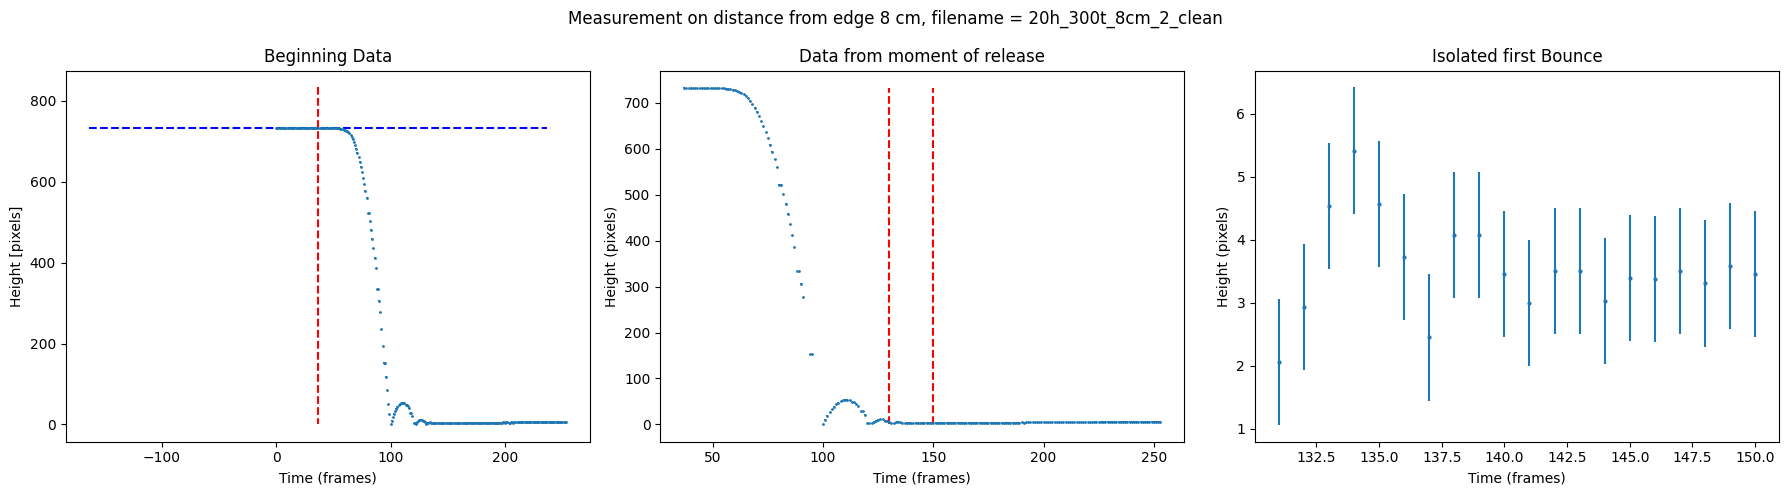

bounce height = 3.672373284049568 pixels
RMSE = 0.71 pixels


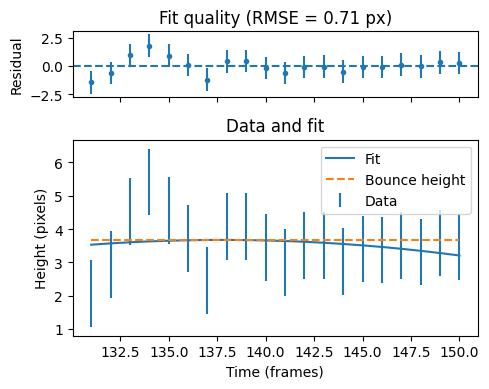

distance from edge = 8 cm
The first 27 frames are deleted, after that the ball drops.
The ball is released at y = 737.5013586956521 pixels.
The minima are located at 0 frames and 44 frames.


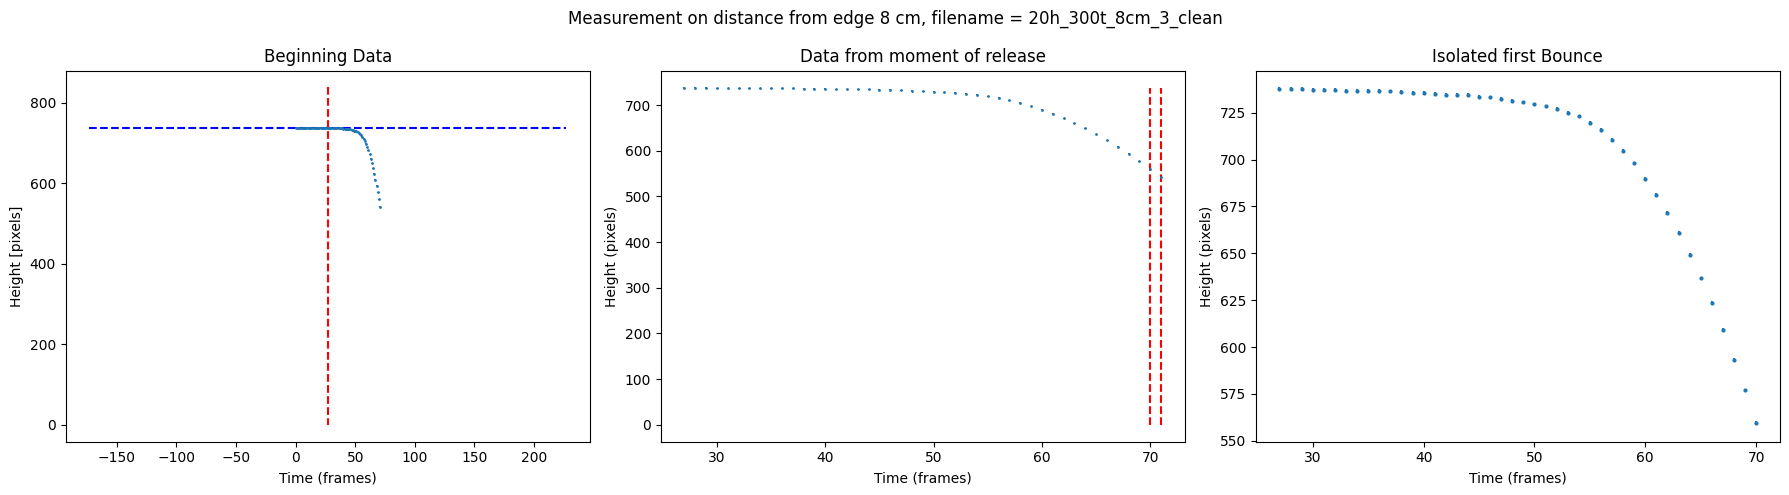

bounce height = 747.6472866803875 pixels
RMSE = 11.09 pixels


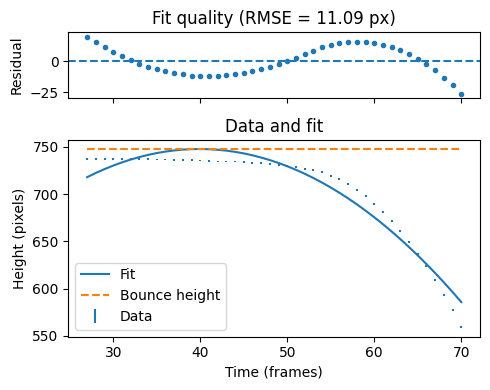

distance from edge = 9 cm
The first 0 frames are deleted, after that the ball drops.
The ball is released at y = 737.4014652014652 pixels.
The minima are located at 61 frames and 92 frames.


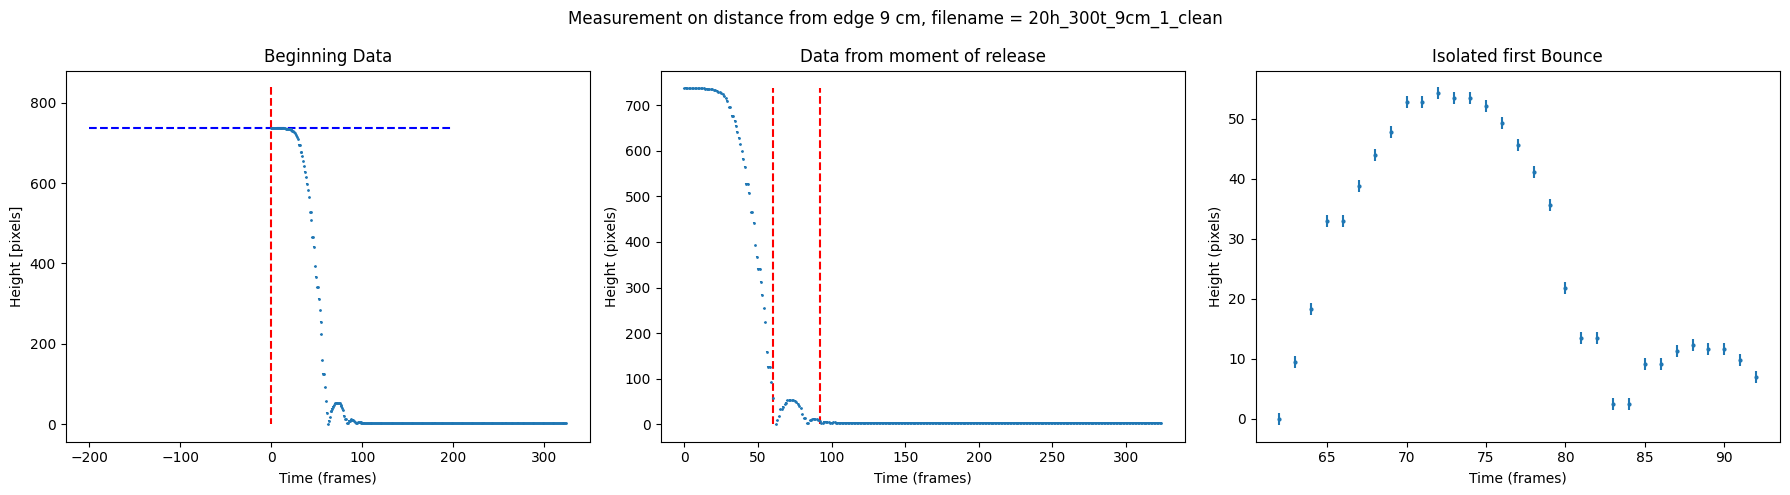

bounce height = 41.325261295174855 pixels
RMSE = 12.55 pixels


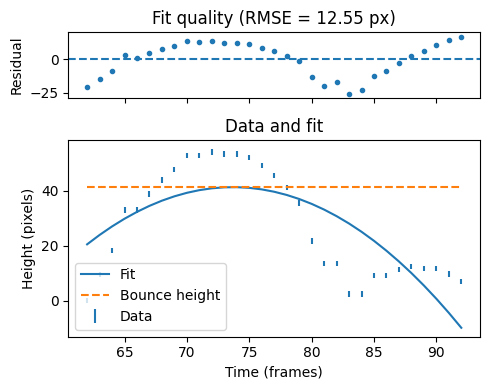

distance from edge = 9 cm
The first 5 frames are deleted, after that the ball drops.
The ball is released at y = 736.4207086343309 pixels.
The minima are located at 91 frames and 96 frames.


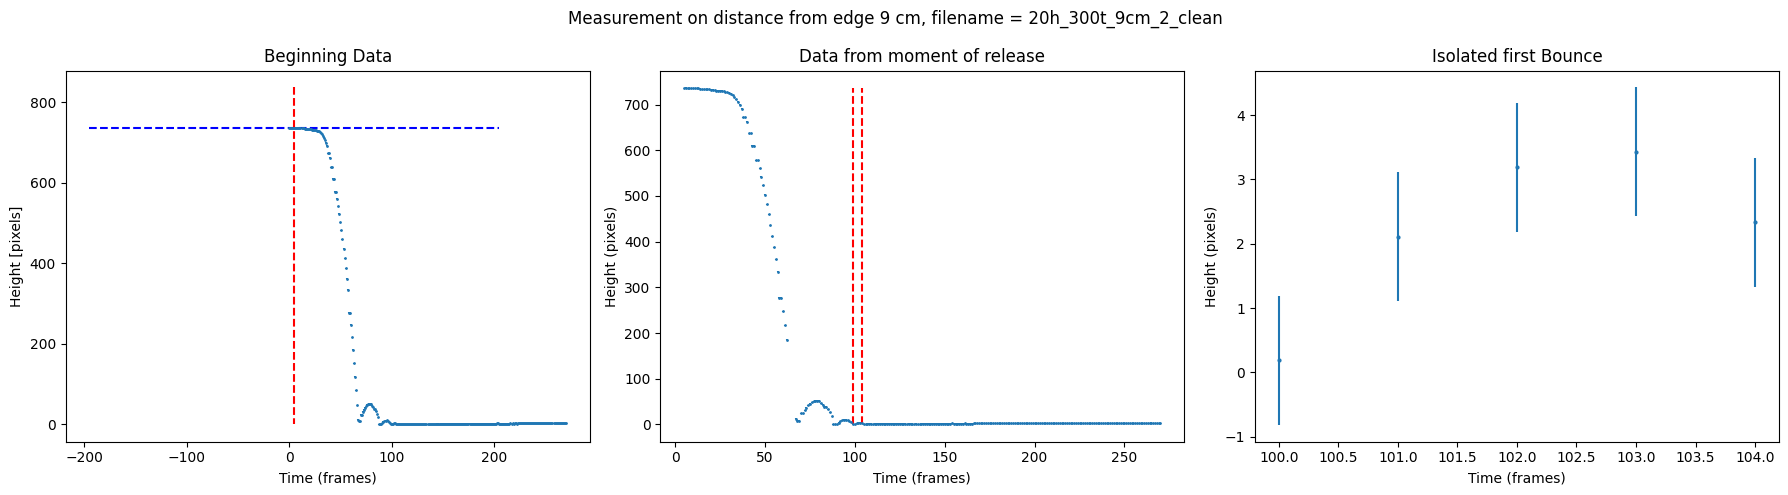

bounce height = 3.3904663447396954 pixels
RMSE = 0.07 pixels


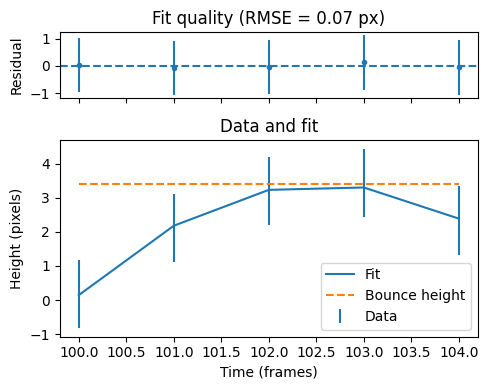

distance from edge = 9 cm
The first 40 frames are deleted, after that the ball drops.
The ball is released at y = 737.5882352941177 pixels.
The minima are located at 54 frames and 75 frames.


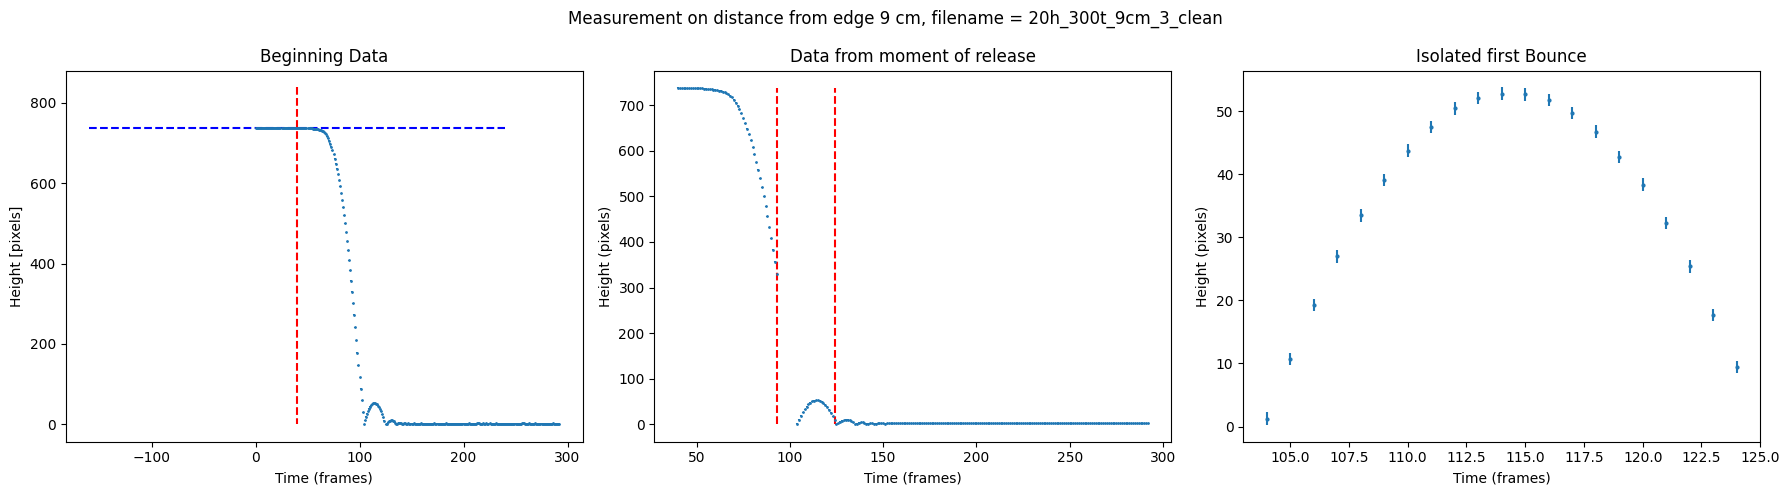

bounce height = 52.968171147961954 pixels
RMSE = 0.14 pixels


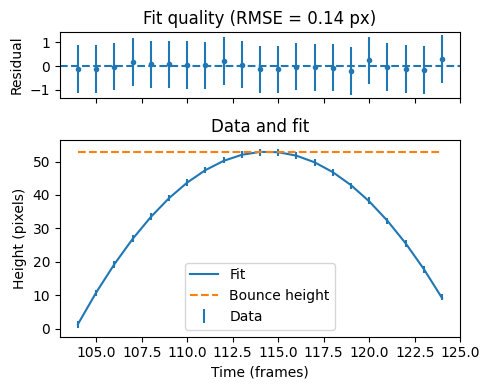

distance from edge = 10 cm
The first 53 frames are deleted, after that the ball drops.
The ball is released at y = 739.2148581329867 pixels.
The minima are located at 63 frames and 96 frames.


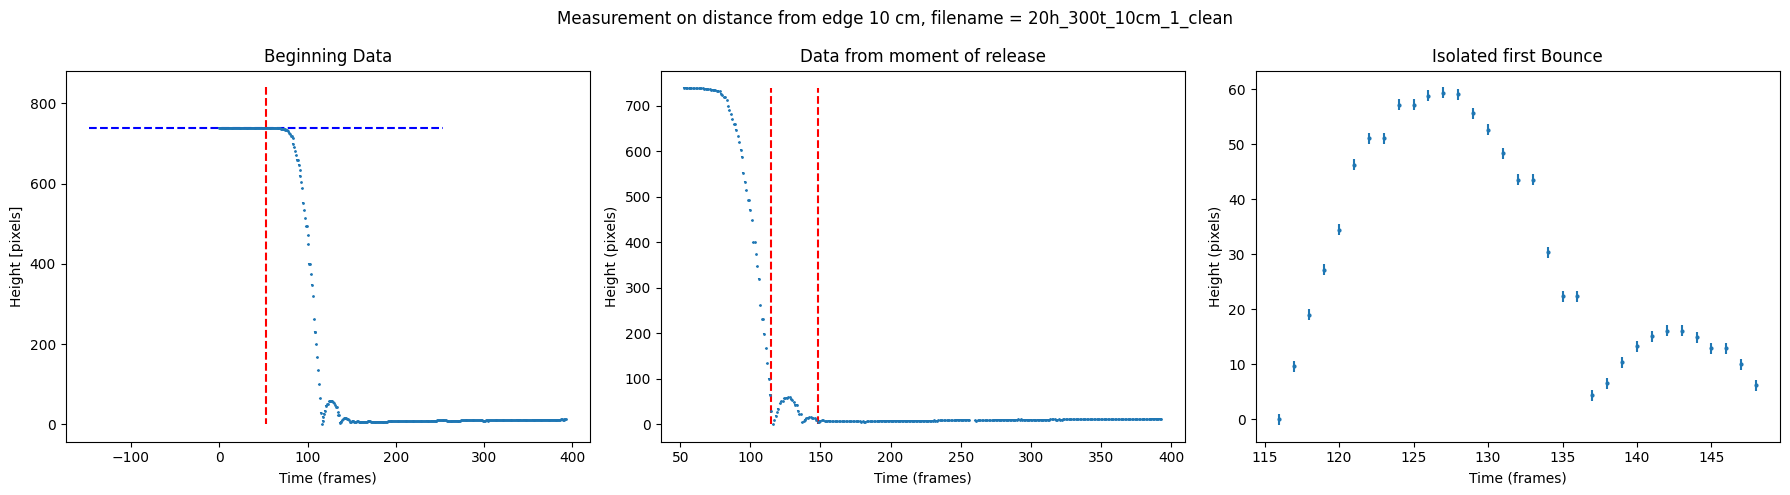

bounce height = 44.142421163972074 pixels
RMSE = 13.35 pixels


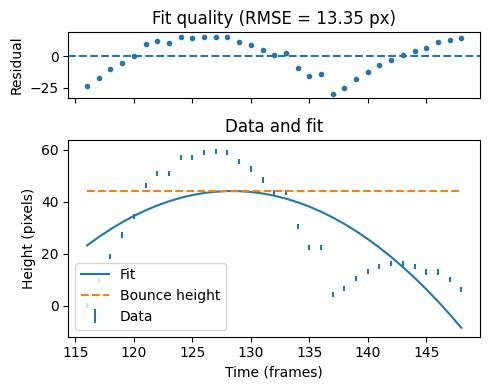

distance from edge = 10 cm
The first 36 frames are deleted, after that the ball drops.
The ball is released at y = 739.2352941176471 pixels.
The minima are located at 60 frames and 82 frames.


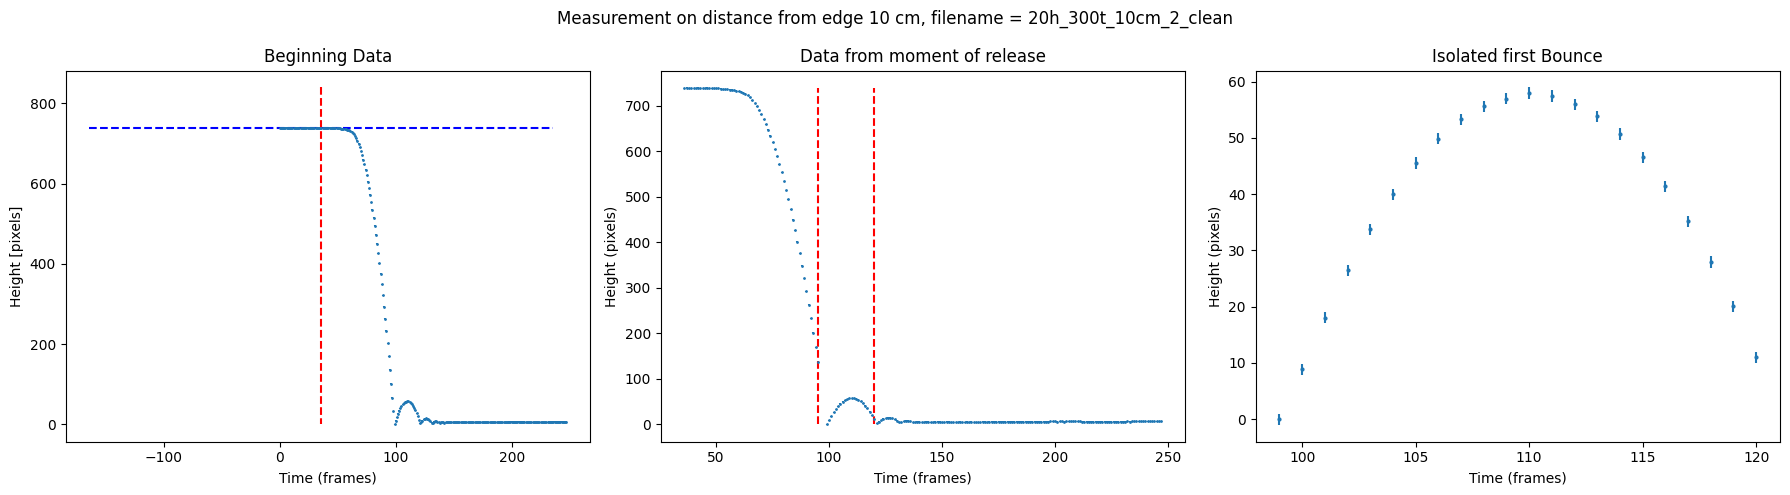

bounce height = 57.78687315692946 pixels
RMSE = 0.24 pixels


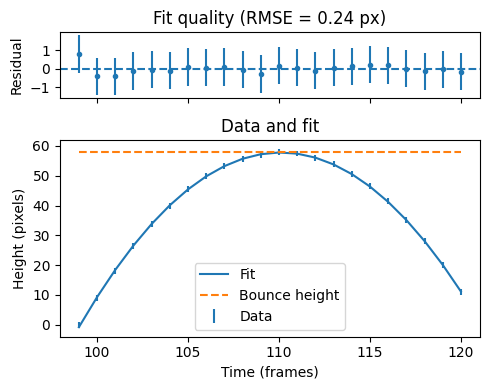

distance from edge = 10 cm
The first 46 frames are deleted, after that the ball drops.
The ball is released at y = 741.7185716182131 pixels.
The minima are located at 62 frames and 84 frames.


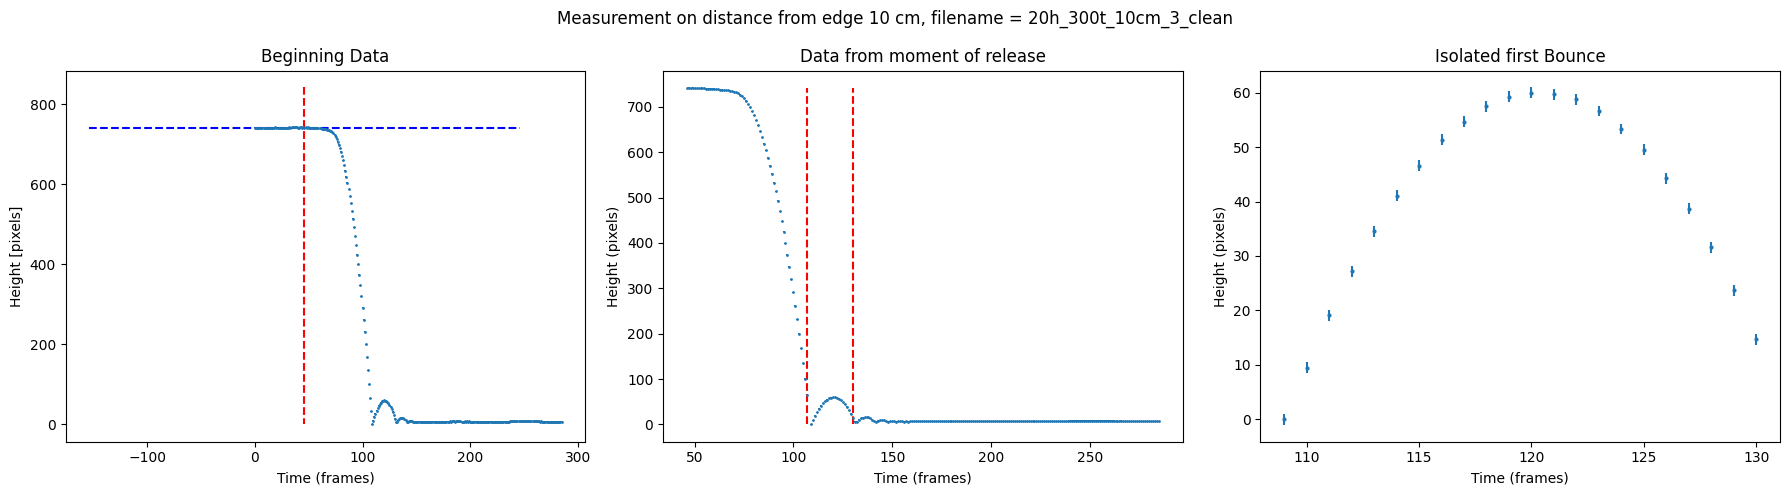

bounce height = 59.94597421593891 pixels
RMSE = 0.19 pixels


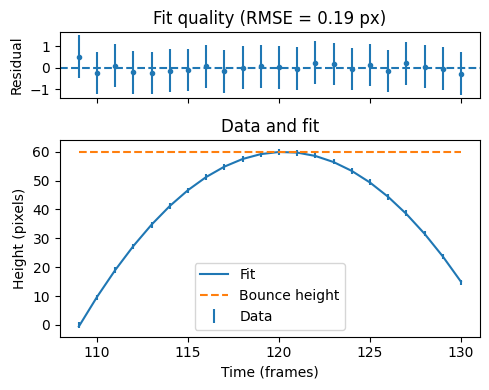

distance from edge = 11 cm
The first 66 frames are deleted, after that the ball drops.
The ball is released at y = 736.4526845245058 pixels.
The minima are located at 64 frames and 91 frames.


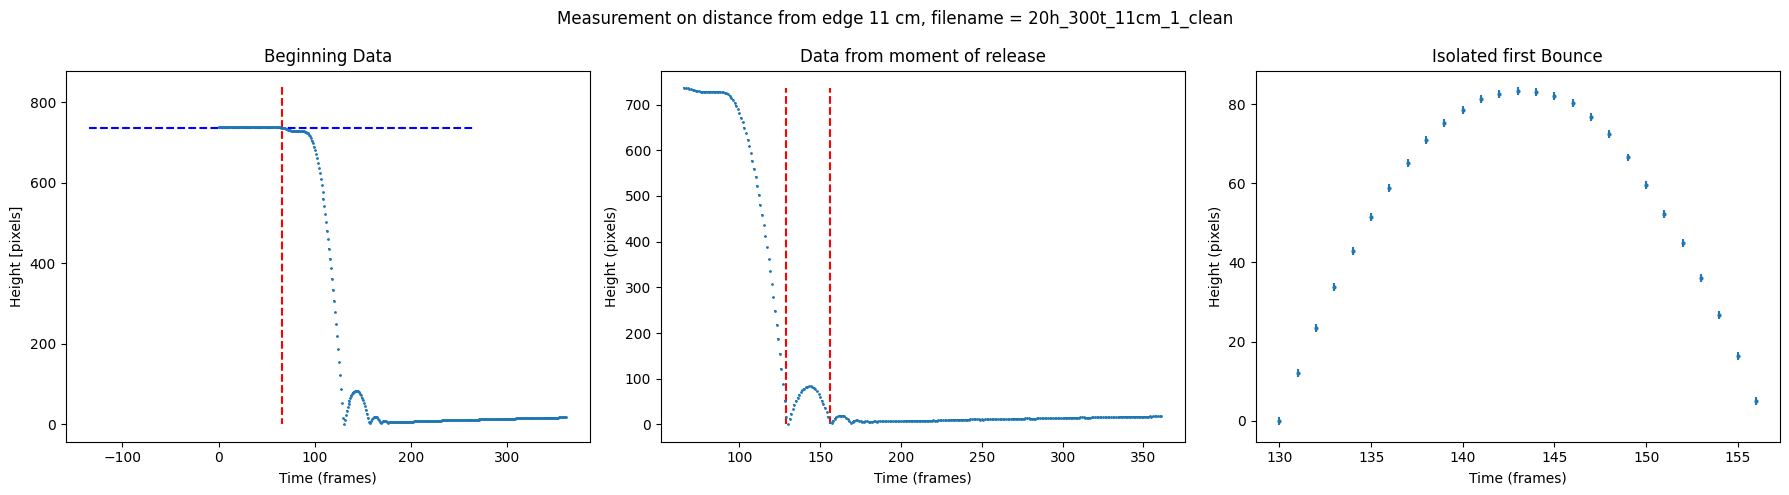

bounce height = 83.30325543506751 pixels
RMSE = 0.53 pixels


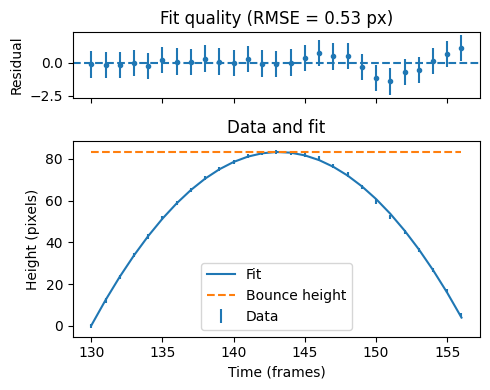

distance from edge = 11 cm
The first 46 frames are deleted, after that the ball drops.
The ball is released at y = 735.157942075913 pixels.
The minima are located at 65 frames and 77 frames.


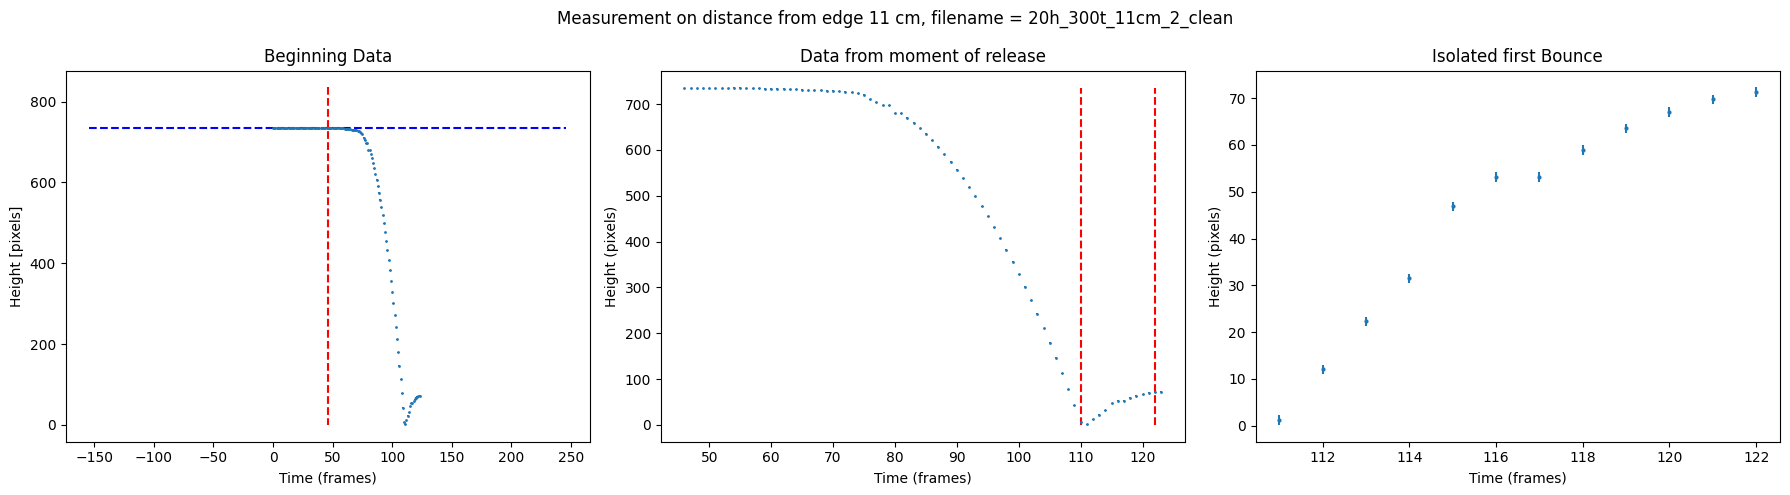

bounce height = 70.03916774186547 pixels
RMSE = 2.20 pixels


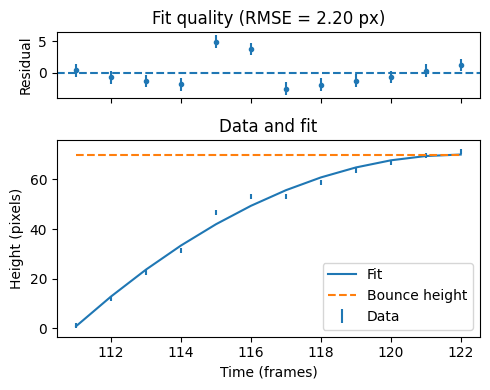

distance from edge = 11 cm
The first 15 frames are deleted, after that the ball drops.
The ball is released at y = 732.4347826086956 pixels.
The minima are located at 56 frames and 81 frames.


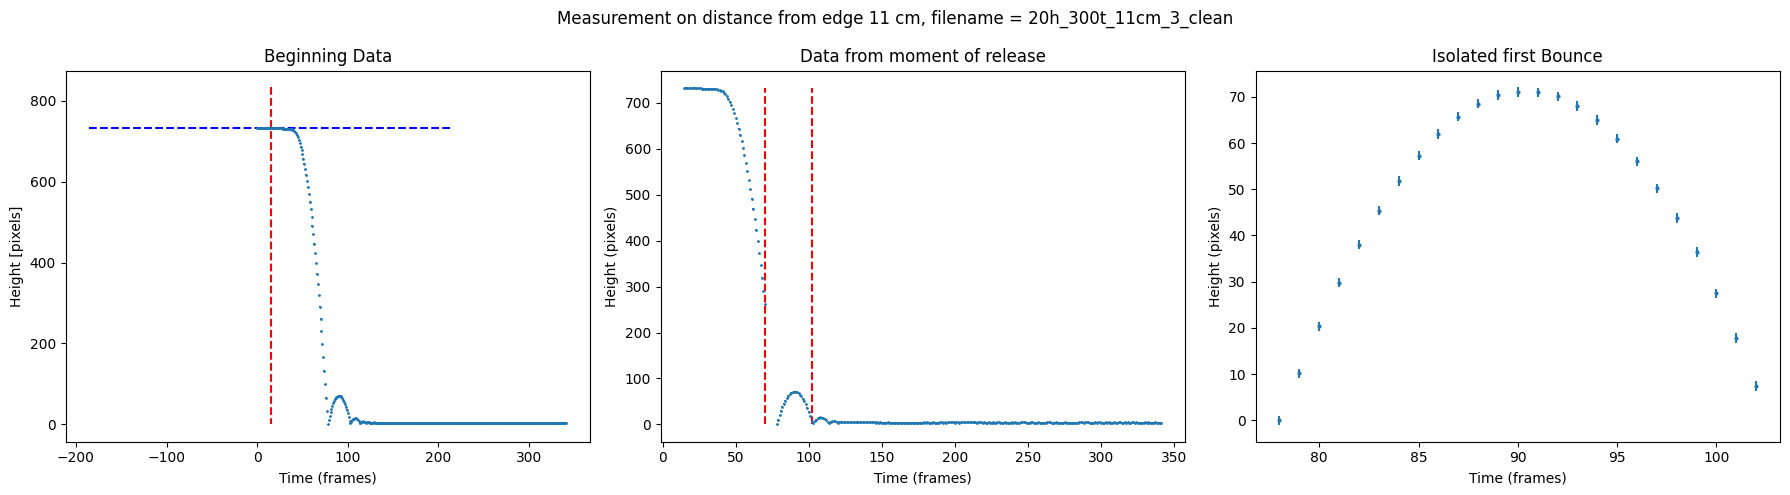

bounce height = 71.05317170146535 pixels
RMSE = 0.24 pixels


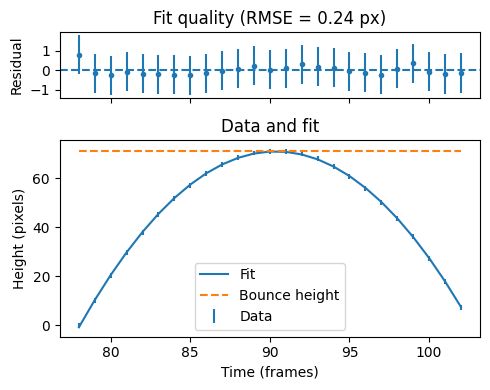

distance from edge = 12 cm
The first 47 frames are deleted, after that the ball drops.
The ball is released at y = 741.8051643192488 pixels.
The minima are located at 58 frames and 87 frames.


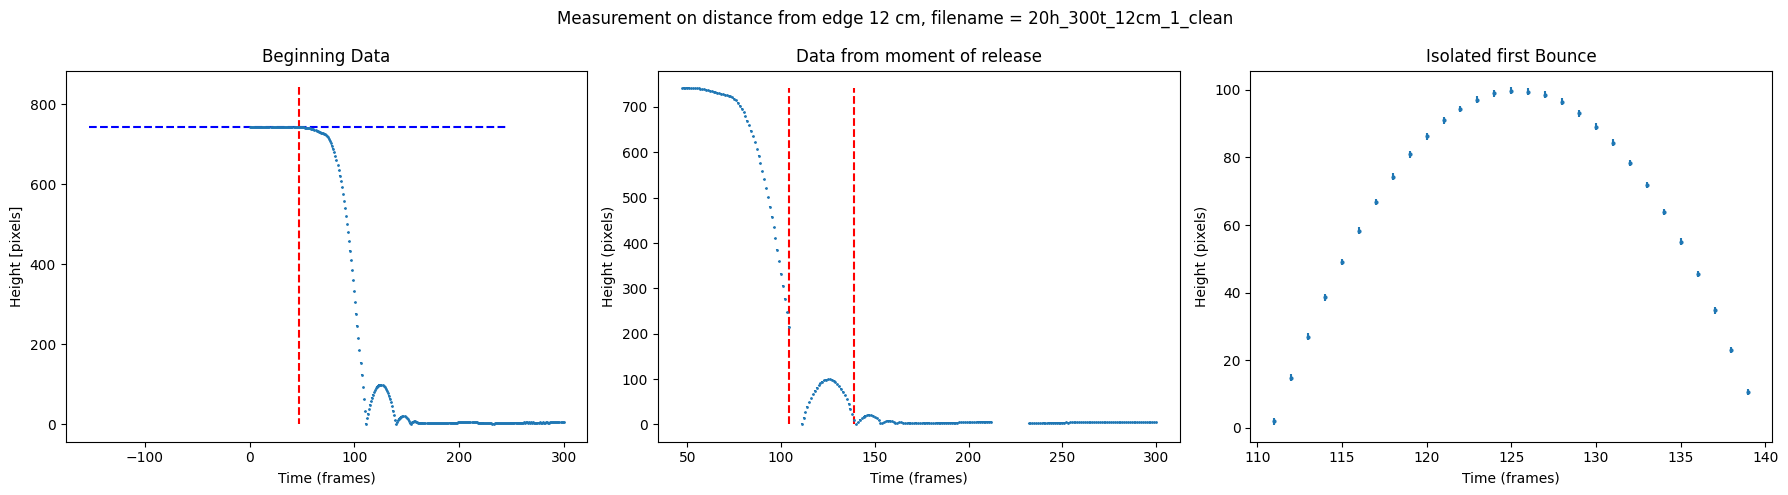

bounce height = 99.78524941392222 pixels
RMSE = 0.13 pixels


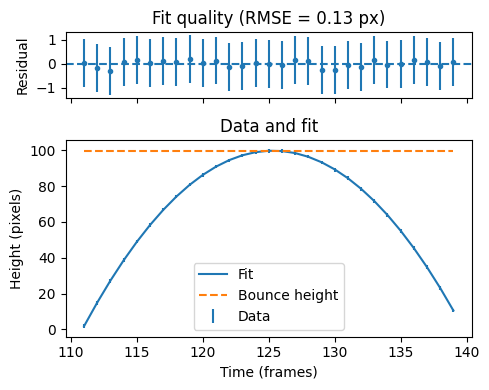

distance from edge = 12 cm
The first 112 frames are deleted, after that the ball drops.
The ball is released at y = 735.8965693804403 pixels.
The minima are located at 47 frames and 76 frames.


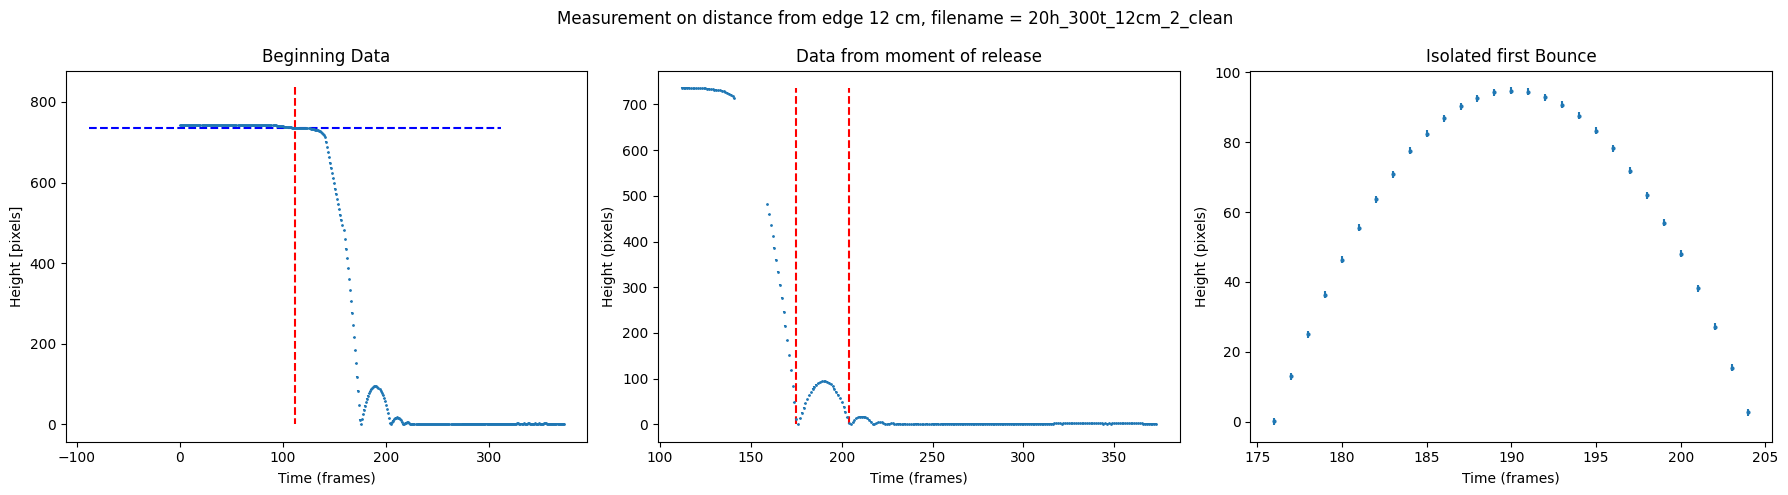

bounce height = 94.8335687057672 pixels
RMSE = 0.12 pixels


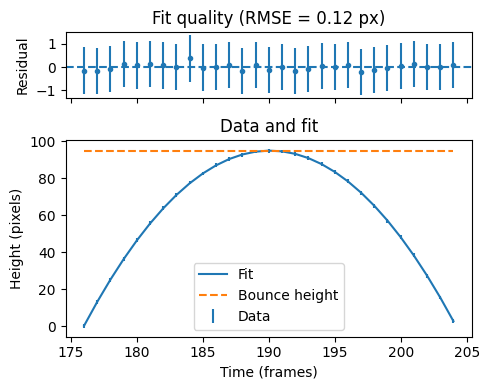

distance from edge = 12 cm
The first 59 frames are deleted, after that the ball drops.
The ball is released at y = 731.4882154882155 pixels.
The minima are located at 62 frames and 90 frames.


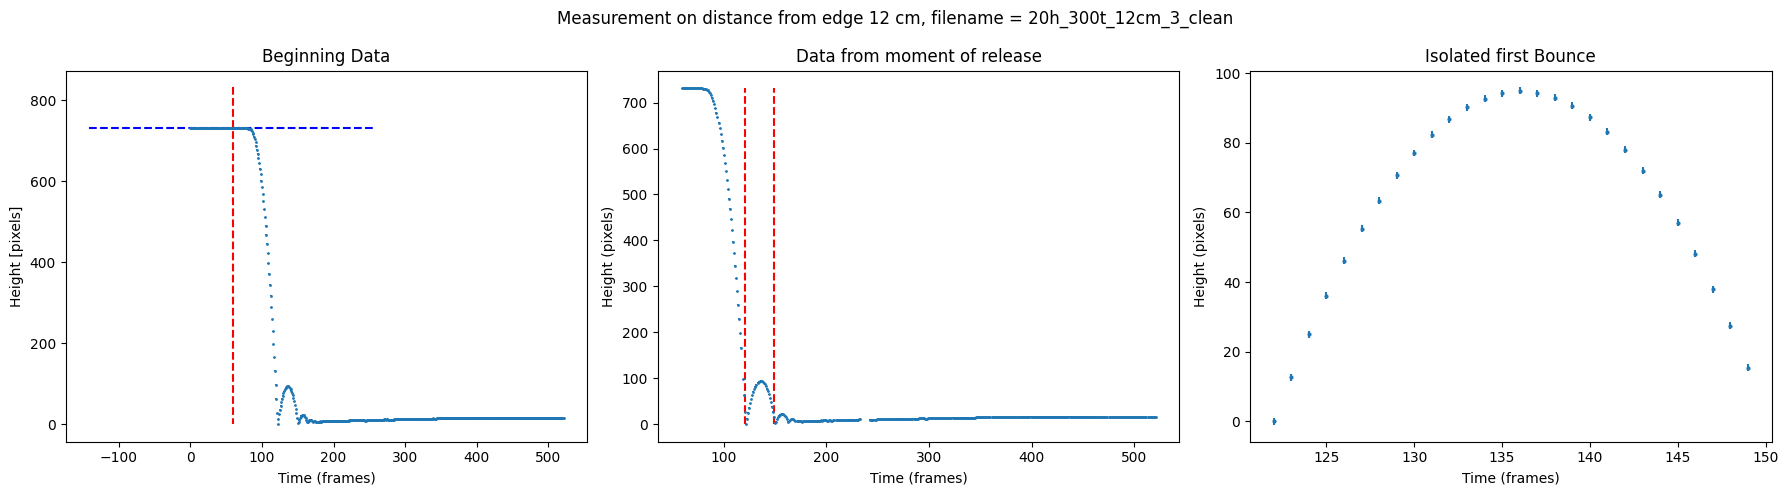

bounce height = 94.68305569315235 pixels
RMSE = 0.10 pixels


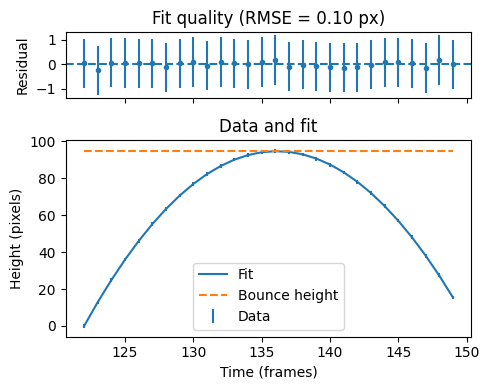

distance from edge = 13 cm
The first 70 frames are deleted, after that the ball drops.
The ball is released at y = 741.8878833584715 pixels.
The minima are located at 63 frames and 94 frames.


KeyboardInterrupt: 

In [44]:
inputfolder = Path(r"Z:\\Clean_Data\Data_Manou_Thesis_Clean\Distance_From_Edge_300t")

variable_type = "distance from edge"
edge = [i for i in range(2, 16) for _ in range(1, 4)]
COR_300t = []

for i in range(2, 16):
    variable_value = f"{i} cm"
    
    for j in range(1, 4):
        filename = f"20h_300t_{i}cm_{j}_clean"
        cor_value = selfmadefunctions.COR_calculator_general(inputfolder=inputfolder, 
                                                                    variable_type=variable_type, 
                                                                    variable_value=variable_value, 
                                                                    filename=filename, Find_Plot=True,
                                                                    Fit_Plot=True, Fit_Report=False)
        COR_300t.append(cor_value)



avg_cor = []
cor_err = []
x = [i for i in range(2, 16)]


for i in range(14):
    temp_cor = []
    for j in range(3):
        temp_cor.append(COR_300t[3*i + j])
    avg_cor.append(sum(temp_cor)/3)
    cor_err.append(np.std(temp_cor)/np.sqrt(3))